# Entanglement Recovery for the divide-and-conquer VQE on the 19-site Kagome lattice

**Goal**
(i) *"Use HVA to convert dimers to the spin-liquid like state for the lower fragment (fragment-2) and then recombine. I am sure the combination will be seamless i.e. Heisenberg gate."*
(ii) *"Entanglement Recovery: If necessary, modify Hamiltonian (not J→J') but by instead adding terms of next nearest neighbours (NNN) terms and you will see the non-local correlations will bring us closer to exact gs_energy."*
His proposed mechanism: *"Heisenberg gates tend to spread non-local correlations by diminishing the desired NN terms (of the original Hamiltonian)."*

**Where Task 2 left us.** The best divide-and-conquer pipeline (exact locals + 24 junction parameters) reached 1.64%, an interface-expressivity floor of 1.6–1.7% measured by triple control. Its microscopy: the junction gates rebuild only 24% of the cut entanglement (0.72 / 3.00 bits) and 31% of the interface energy (−1.73 / −5.53); the exact ground state *pays* +4.4 of intra-region energy to *gain* −5.5 at the interface; and fragment 2's frozen dimers sit at the −3/0 bond pattern while the ED wants every fragment bond at −1.0…−1.9 (×4 convention).

**Working hypothesis** — *matching the fragments' correlation profiles before joining makes the recombination seamless* (registered as a prediction scorecard before any Task-3 optimization was run):

| # | Prediction | Task-2 evidence it extends |
|---|------------|---------------------------|
| **P1** | With fragment 2 dressed, the frozen start stops being stationary: $\|\nabla E\|_{\theta=0} > 0$, and the ~65-iteration plateau of the junction VQE disappears. | measured $\|\nabla E\|_{\theta=0} = 1.5\times10^{-15}$, plateau to it≈65 |
| **P2** | A dressed pipeline pierces the Task-2 interface floor (1.6–1.7% @ 24 junction params), approaching the monolithic references (0.80% @ 120p, 0.52% @ 180p). | floor measured by triple control |
| **P3** | The RMS distance between fragment-2 correlations and the ED-restricted profile predicts the final error better than the fragment's local energy does. | "energy converges before correlations" (Tasks 1–2) |

**Design amendment (registered, §3.1).** The λ pre-analysis below showed that the dimer cover remains the *exact* ground state of $H_{NN}+\lambda H_{NNN}$ over a finite window (a Majumdar–Ghosh-type stability), so a fourth configuration **D** (fragment dressed by *direct correlation fit* to the §1 target) was added as the strongest realizable form of "convert fragment 2 into the spin-liquid-like state". Everything is still reported, measured, in the scorecard.

**Conventions.** Energies use the project's ×4 convention $H=\sum_{(i,j)}(X_iX_j+Y_iY_j+Z_iZ_j)$ (singlet bond = −3, $J=1$ uniform — *no calibration anywhere*). The training Hamiltonian of §3 is $H_{\rm train}=H_{NN}+\lambda\sum_{NNN}(XX+YY+ZZ)$ with both terms in the ×4 convention, so **λ = J₂/J₁** directly. The reported metric is always the original uncalibrated $H$. Correlations are $\langle S_i\!\cdot\!S_j\rangle$ (singlet = −0.75). Fidelities are subspace projections onto the full degenerate ground manifold; every optimization uses ≥5 seeds where budgets allow (the λ sweep uses 3 seeds at a fixed reduced budget, stated in place).

All new logic lives in [`kagome_er.py`](kagome_er.py) (documented like its predecessors); Task-1/2 engines are imported from `../1_Task/` and `../2_Task/`, never copied. Heavy cells persist to `results/*.npz` and auto-load.

**Sections.** §1 the target profile · §2 testbed, stationarity theorem, configs A/B · §3 the λ machinery: pre-analysis, sweep (C), λ*, profile-matched dressing (D), traces, the trade, P3 · §4 26 sites: dressing transfer and the second SU(2) sectorization · §5 scorecard and discussion · §6 from diagnosis to improvement (interface capacity: the measured lever).

In [1]:
# --- Environment: reuse Tasks 1-2 wholesale, add only the ER layer ---
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "kagome_er.py").exists():          # kernel started elsewhere
    HERE = Path("/home/tesla/Qintern2026/3_Task")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import kagome_er as er     # Task-3 module (this folder); pulls in dc and K
import kagome_dc as dc     # Task-2 engine — imported
import kagome_hva as K     # Task-1 engine

RESULTS, FIGURES = HERE / "results", HERE / "figures"
RESULTS.mkdir(exist_ok=True); FIGURES.mkdir(exist_ok=True)
T2_RESULTS = HERE.parent / "2_Task" / "results"

SEEDS = (0, 1, 2, 3, 4)
C_R1, C_R2, C_IF, C_T1 = dc.COLOR_R1, dc.COLOR_R2, dc.COLOR_IFC, dc.COLOR_T1

# Exact 19-site references (Task-2 cache)
edges_19, dimers_19 = dc.load_task1_lattice()
_d = np.load(T2_RESULTS / "ed19.npz")
E19, evals19, V19 = float(_d["E0"]), _d["evals"], _d["V"]
psi19_up = dc.project_sz(V19, 19, +0.5)[:, 0]     # S_z=+1/2 doublet component
print(f"kagome_er : {er.__file__}")
print(f"kagome_dc : {dc.__file__}")
print(f"E19 = {E19:.6f}   (ground manifold: doublet, dim {V19.shape[1]})")

kagome_er : /home/tesla/Qintern2026/3_Task/kagome_er.py
kagome_dc : /home/tesla/Qintern2026/2_Task/kagome_dc.py
E19 = -29.146168   (ground manifold: doublet, dim 2)


## 1. The target profile: what "spin-liquid-like" means in numbers

Fragment 2 (sites 11–18) is special: its dimer cover $(11,12)(13,14)(15,16)(17,18)$ is its exact local ground state (Majumdar–Ghosh mechanism, Task-2 §2), so *locally* there is nothing to improve. The 19-site ED disagrees globally: restricted to the fragment it weakens every dimer and strengthens every non-dimer bond, that redistribution (*resonance*), not any large NNN correlation, is what "spin-liquid-like" means here. This section turns into contrastable numbers: the ED-restricted correlation profile on the fragment's NN bonds, on its NNN pairs, and the entanglement entropy across every cut.

Two design rules, per the task spec: the NNN pairs are derived programmatically (graph distance exactly 2 inside the induced fragment subgraph, using the real bonds, never a hand list), and $\langle S_i\!\cdot\!S_j\rangle$ is an SU(2) scalar, so the profile is identical for either $S_z$ component of the 19-site doublet; we use the $S_z=+1/2$ projection.

fragment-2 NN bonds (10): [(11, 12), (12, 13), (12, 14), (13, 14), (14, 15), (14, 16), (15, 16), (16, 17), (17, 18), (16, 18)]
fragment-2 NNN pairs (10), global: [(11, 13), (11, 14), (12, 15), (12, 16), (13, 15), (13, 16), (14, 17), (14, 18), (15, 17), (15, 18)]
                       local (s -> s-11)  : [(0, 2), (0, 3), (1, 4), (1, 5), (2, 4), (2, 5), (3, 6), (3, 7), (4, 6), (4, 7)]
cross-cut lattice-NNN pairs inside the fragment: [(11, 17)]


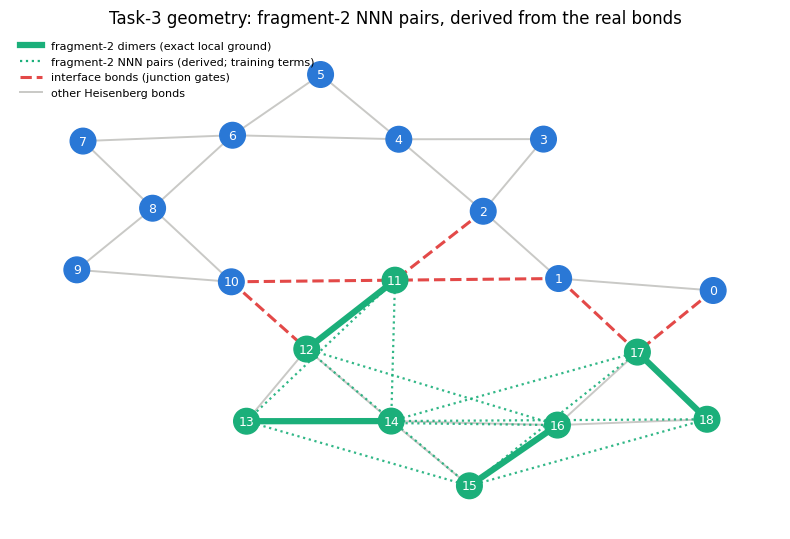

In [2]:
# NNN pairs of fragment 2, DERIVED (graph distance 2 in the induced subgraph)
nnn_g, nnn_l = er.fragment2_nnn()
assert len(nnn_g) == 10
print(f"fragment-2 NN bonds ({len(dc.SUB2_EDGES)}): {dc.SUB2_EDGES}")
print(f"fragment-2 NNN pairs ({len(nnn_g)}), global: {nnn_g}")
print(f"                       local (s -> s-11)  : {nnn_l}")

# Pairs inside the fragment that are distance-2 only THROUGH the cut are NOT
# in the subgraph set; there is exactly one, via junction site 1. Sec. 1
# checks below that the ED barely correlates it (so nothing is lost).
import networkx as nx
Gful = nx.Graph([tuple(e) for e in edges_19])
G2 = nx.Graph([tuple(e) for e in dc.SUB2_EDGES])
dful = dict(nx.all_pairs_shortest_path_length(Gful, cutoff=2))
d2 = dict(nx.all_pairs_shortest_path_length(G2))
cross = sorted({tuple(sorted((u, v))) for u in dc.SUB2_SITES
                for v, l in dful[u].items() if v in dc.SUB2_SITES
                and u != v and l == 2 and d2[u].get(v, 99) > 2})
print(f"cross-cut lattice-NNN pairs inside the fragment: {cross}")

# --- figure: the Task-3 geometry --------------------------------------------
from matplotlib.lines import Line2D
pos = nx.kamada_kawai_layout(Gful)
IFC = {tuple(sorted(e)) for e in dc.INTERFACE_EDGES}
D2s = {tuple(sorted(dm)) for dm in dc.SUB2_DIMERS}
fig, ax = plt.subplots(figsize=(8, 5.5))
plain = [e for e in Gful.edges if tuple(sorted(e)) not in IFC | D2s]
nx.draw_networkx_edges(Gful, pos, edgelist=plain, edge_color="#c9c9c6",
                       width=1.4, ax=ax)
nx.draw_networkx_edges(Gful, pos, edgelist=[e for e in Gful.edges
                       if tuple(sorted(e)) in D2s],
                       edge_color=C_R2, width=4.5, ax=ax)
nx.draw_networkx_edges(Gful, pos, edgelist=[e for e in Gful.edges
                       if tuple(sorted(e)) in IFC],
                       edge_color=C_IF, width=2.2, style="dashed", ax=ax)
nx.draw_networkx_edges(nx.Graph(nnn_g), pos, edgelist=nnn_g, edge_color=C_R2,
                       width=1.6, style="dotted", alpha=0.9, ax=ax)
nx.draw_networkx_nodes(Gful, pos, node_color=[C_R1 if v <= 10 else C_R2
                       for v in Gful.nodes], node_size=340, ax=ax)
nx.draw_networkx_labels(Gful, pos, font_size=9, font_color="white", ax=ax)
ax.legend(handles=[
    Line2D([], [], color=C_R2, lw=4.5, label="fragment-2 dimers (exact local ground)"),
    Line2D([], [], color=C_R2, lw=1.6, ls=":", label="fragment-2 NNN pairs (derived; training terms)"),
    Line2D([], [], color=C_IF, lw=2.2, ls="--", label="interface bonds (junction gates)"),
    Line2D([], [], color="#c9c9c6", lw=1.4, label="other Heisenberg bonds"),
], loc="upper left", fontsize=8, frameon=False)
ax.set_title("Task-3 geometry: fragment-2 NNN pairs, derived from the real bonds")
ax.axis("off"); fig.tight_layout()
fig.savefig(FIGURES / "er_nnn_lattice.png", dpi=150, bbox_inches="tight")
plt.show()

loaded er19_target.npz

<S_i.S_j> (singlet = -0.75)      ED target   bare dimers
  NN   (11, 12):  -0.1982     -0.7500  <- dimer bond
  NN   (12, 13):  -0.2668     +0.0000
  NN   (12, 14):  +0.0056     +0.0000
  NN   (13, 14):  -0.4695     -0.7500  <- dimer bond
  NN   (14, 15):  -0.3333     +0.0000
  NN   (14, 16):  +0.0034     +0.0000
  NN   (15, 16):  -0.4010     -0.7500  <- dimer bond
  NN   (16, 17):  +0.0034     -0.0000
  NN   (17, 18):  -0.3333     -0.7500  <- dimer bond
  NN   (16, 18):  -0.4010     +0.0000
  NNN  (11, 13):  +0.0317     +0.0000
  NNN  (11, 14):  -0.0126     +0.0000
  NNN  (12, 15):  -0.0101     +0.0000
  NNN  (12, 16):  +0.0028     +0.0000
  NNN  (13, 15):  +0.0565     +0.0000
  NNN  (13, 16):  -0.0100     +0.0000
  NNN  (14, 17):  +0.0024     +0.0000
  NNN  (14, 18):  -0.0095     +0.0000
  NNN  (15, 17):  -0.0095     +0.0000
  NNN  (15, 18):  +0.0556     -0.0000

fragment-2 intra energy of the target: -9.5621   (exact local ground: -12  ->  the ED 'pays' +2.43

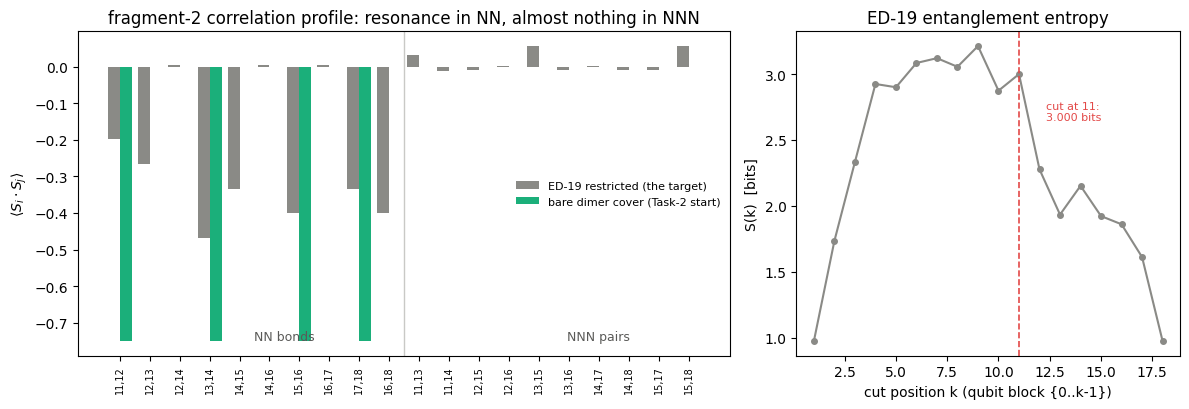

In [3]:
# --- The target profile: ED-19 ground state restricted to fragment 2 --------
TG_FILE = RESULTS / "er19_target.npz"
if TG_FILE.exists():
    _t = np.load(TG_FILE)
    pnn  = [tuple(int(x) for x in p) for p in _t["pairs_nn"]];  vnn  = _t["vals_nn"]
    pnnn = [tuple(int(x) for x in p) for p in _t["pairs_nnn"]]; vnnn = _t["vals_nnn"]
    pifc = [tuple(int(x) for x in p) for p in _t["pairs_ifc"]]; vifc = _t["vals_ifc"]
    dim_nn, dim_nnn, ent_ed = _t["dim_nn"], _t["dim_nnn"], _t["ent_ed"]
    print(f"loaded {TG_FILE.name}")
else:                                             # 19q correlations + 18 SVDs
    tg0 = er.ed_fragment_targets(psi19_up)
    ent_ed = np.array(K.entanglement_entropy_cuts(19, psi19_up)[::-1])  # physical blocks {0..k-1}
    sv_dim0 = er.dressed_fragment_state([], 0)
    prof0 = er.fragment_profile(sv_dim0)
    pnn = [tuple(e) for e in dc.SUB2_EDGES]; pnnn = er.fragment2_nnn()[0]
    pifc = [tuple(e) for e in dc.INTERFACE_EDGES]
    vnn = np.array([tg0["nn"][p] for p in pnn])
    vnnn = np.array([tg0["nnn"][p] for p in pnnn])
    vifc = np.array([tg0["interface"][p] for p in pifc])
    dim_nn = np.array([prof0[p] for p in pnn])
    dim_nnn = np.array([prof0[p] for p in pnnn])
    np.savez(TG_FILE, pairs_nn=np.array(pnn), vals_nn=vnn, pairs_nnn=np.array(pnnn),
             vals_nnn=vnnn, pairs_ifc=np.array(pifc), vals_ifc=vifc,
             dim_nn=dim_nn, dim_nnn=dim_nnn, ent_ed=ent_ed)
    print(f"computed -> {TG_FILE.name}")

tg = dict(nn=dict(zip(pnn, vnn)), nnn=dict(zip(pnnn, vnnn)),
          interface=dict(zip(pifc, vifc)))
dimset = {tuple(sorted(dm)) for dm in dc.SUB2_DIMERS}
print(f"\n<S_i.S_j> (singlet = -0.75)      ED target   bare dimers")
for p, v, w in zip(pnn, vnn, dim_nn):
    tag = "  <- dimer bond" if tuple(sorted(p)) in dimset else ""
    print(f"  NN  {str(p):>9s}:  {v:+.4f}     {w:+.4f}{tag}")
for p, v, w in zip(pnnn, vnnn, dim_nnn):
    print(f"  NNN {str(p):>9s}:  {v:+.4f}     {w:+.4f}")

prof_dim = {**dict(zip(pnn, dim_nn)), **dict(zip(pnnn, dim_nnn))}
rms_nn_d, rms_nnn_d, rms_all_d = er._rms_triple(prof_dim, tg)
e_nn_target = 4 * float(np.sum(vnn))              # x4 convention
print(f"\nfragment-2 intra energy of the target: {e_nn_target:.4f}   "
      f"(exact local ground: -12  ->  the ED 'pays' {e_nn_target + 12:+.4f} here)")
print(f"ED interface energy (6 cut bonds)    : {4 * float(np.sum(vifc)):.4f}")
print(f"dimer-cover RMS vs target: NN {rms_nn_d:.4f} | NNN {rms_nnn_d:.4f} | "
      f"all {rms_all_d:.4f}")
print(f"cross-cut pair (11,17) in the ED     : "
      f"{K.pair_correlations(19, psi19_up, [(11, 17)])[(11, 17)]:+.4f}  "
      f"(negligible -> subgraph-NNN loses nothing)")
assert abs(ent_ed[10] - 3.0) < 5e-3   # the 3.000 bits the junctions must rebuild

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), width_ratios=[1.7, 1])
ax = axes[0]
xs = np.arange(len(pnn) + len(pnnn))
tv = np.concatenate([vnn, vnnn]); dv = np.concatenate([dim_nn, dim_nnn])
ax.bar(xs - 0.2, tv, width=0.4, color=C_T1, label="ED-19 restricted (the target)")
ax.bar(xs + 0.2, dv, width=0.4, color=C_R2, label="bare dimer cover (Task-2 start)")
ax.axvline(len(pnn) - 0.5, color="#c9c9c6", lw=1)
ax.set_xticks(xs)
ax.set_xticklabels([f"{a},{b}" for a, b in pnn + pnnn], rotation=90, fontsize=7)
ax.text(0.27, 0.05, "NN bonds", transform=ax.transAxes, fontsize=9, color="#5a5a58")
ax.text(0.75, 0.05, "NNN pairs", transform=ax.transAxes, fontsize=9, color="#5a5a58")
ax.set_ylabel(r"$\langle S_i\cdot S_j\rangle$")
ax.legend(fontsize=8, frameon=False)
ax.set_title("fragment-2 correlation profile: resonance in NN, almost nothing in NNN")
ax2 = axes[1]
ax2.plot(range(1, 19), ent_ed, "o-", color=C_T1, ms=4)
ax2.axvline(11, color=C_IF, ls="--", lw=1.2)
ax2.annotate(f"cut at 11:\n{ent_ed[10]:.3f} bits", xy=(11, ent_ed[10]),
             xytext=(12.3, ent_ed[10] - 0.35), fontsize=8, color=C_IF)
ax2.set_xlabel("cut position k (qubit block {0..k-1})")
ax2.set_ylabel("S(k)  [bits]")
ax2.set_title("ED-19 entanglement entropy")
fig.tight_layout()
fig.savefig(FIGURES / "er_target_profile.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading.** The ED does not build NNN correlations; it *resonates* the NN network. On the fragment's dimer bonds the restricted profile weakens from $-0.75$ to $-0.20\ldots-0.47$, while every non-dimer NN bond strengthens from $0$ to $-0.27\ldots-0.40$; the ten NNN correlations stay at $|\langle S_iS_j\rangle|\le 0.06$, the bare dimer cover already matches them to rms **0.028**. Two consequences frame everything below. First, the measurable meaning of *"convert the dimers into the spin-liquid-like state"* is **NN resonance, not NNN structure**, an important nuance for the NNN-training tool of §3. Second, the resonance is not free: restricted to the fragment, the ED state has $\langle H_{NN}\rangle = -9.56$, i.e. it **pays +2.44** of local energy (the exact local ground is $-12$) to earn $-5.53$ at the interface the trade the junctions must reproduce. The single cross-cut NNN pair $(11,17)$ carries $-0.013$ in the ED, so the programmatic subgraph definition of the NNN set loses nothing.

## 2. The testbed, a stationarity theorem, and configs A/B

**Testbed (fixed for all of §2–3).** Subregion 1 is frozen at the Task-2 *exact-local* optimum (spinon on site 0, reps=1, 14 local params; it IS the local ground doublet; `er.exact_local_sub1` asserts $E_1=-16$ on rebuild). Fragment 2's preparation is therefore the only experimental variable, and the junction stage is always 4 per-bond layers on the 6 cut bonds (24 params) optimized against the full uncalibrated $H$ directly comparable to the Task-2 floor.

| config | fragment-2 preparation | shaped by | junction stage |
|---|---|---|---|
| **A** | bare dimer cover (exact local ground) | — | 24p, 5 seeds × 400 its (Task-2 §9.1, reused) |
| **B** | $k$ HVA layers, optimized **jointly** with the junctions | full 19q $H$ | $10k{+}24$p together, 5 seeds × (300+200) its |
| **C** | pre-trained vs $H_{NN}+\lambda H_{NNN}$, then frozen | fragment $H_{\rm train}$ | 24p, 3 seeds × 200 its (sweep budget, §3) |
| **D** | pre-dressed by direct correlation fit to the §1 target, then frozen | §1 profile | 24p, 5 seeds × 400 its (§3.3) |

**A stationarity theorem (why P1 was doomed at registration).** For a junction gate $U_H(\theta)=e^{-i\theta M}$ with $M=\tfrac14(XX+YY+ZZ)_{ij}$ across the cut, $\partial_\theta E|_{\theta=0}=i\langle[M,H]\rangle$. Every term of $[M,H]$ factorizes across the cut into products of one- and two-site spin operators, and on a product $|\psi_1\rangle\otimes|\psi_2\rangle$ whose factors are exact $S^2$ eigenstates Wigner–Eckart kills each factor: in a singlet every vector operator has $\langle\sigma^a\rangle=0$ and every two-site factor is $\langle\sigma^a_x\sigma^b_y\rangle=\delta_{ab}C_{xy}$, whose $\delta_{ab}$ meets the commutator's $\varepsilon_{abc}$ ($\varepsilon_{abb}=0$). So the identity is exactly stationary for any dressing that keeps fragment 2 an $S=0$ state which every Heisenberg-gate dressing does, since $U_H$ commutes with $S^2$. Task 2 attributed its measured $1.5\times10^{-15}$ to the fragments being local *eigenstates*; the correct statement is stronger: the stationarity is **symmetry-protected**. (The Clebsch–Gordan start of the 26-site chain is *not* a product across the cut, and Task 2 indeed measured $|\nabla E|=5.4\times10^{-3}$ there the exception that proves the rule; §4.) What "seamless" can still mean and what we measure is whether the junction VQE *lands lower* from a dressed start.

In [4]:
# --- Config A: the Task-2 exact-local pipeline, reused as the control --------
sv1, x1_alt, sim1_alt = er.exact_local_sub1()     # asserts E1 = -16 exactly
psiF_A = dc.embed_product(sv1, er.dressed_fragment_state([], 0))
rec_A = dc.RecombinationVQE(psiF_A, edges_full=edges_19)
eF_A = rec_A.energy(psiF_A)
print(f"baseline frozen start: E = {eF_A:.6f}   err = "
      f"{abs(eF_A - E19)/abs(E19)*100:.3f}%   (both locals are EXACT: this is "
      f"the naive bound)")
_, g0_A = rec_A.gradient_at_zero(reps=1)
print(f"|grad E| at theta=0: {g0_A:.3e}   (P1 baseline; Task 2 measured 1.5e-15)")

runs_A = dc.load_runs(T2_RESULTS / "dnc19_alt.npz")     # Task-2 Sec. 9.1 result
stA = dc.summarize_runs(runs_A)
best_A = min(runs_A, key=lambda r: r["err_pct"])
gain_A = best_A["energy"] - eF_A
print(f"\nconfig A (junction VQE only: 24p, 5 seeds, maxiter=400 — Task-2 9.1):")
print(f"  err = {stA['err_pct'][0]:.3f} ± {stA['err_pct'][1]:.3f} %   "
      f"best {best_A['err_pct']:.3f}%   E_best = {best_A['energy']:.4f}   "
      f"fid = {stA['fidelity'][0]:.3f}")
print(f"  junction interface gain: {gain_A:+.4f}   "
      f"(ED interface total: {4*float(np.sum(vifc)):.4f})")
print(f"\nthe bar for P2: pierce {best_A['err_pct']:.3f}% (floor 1.6-1.7% by "
      f"triple control);\nmonolithic Task-1 references: 0.80% @ 120p, 0.52% @ 180p")

baseline frozen start: E = -28.000000   err = 3.932%   (both locals are EXACT: this is the naive bound)


|grad E| at theta=0: 1.677e-17   (P1 baseline; Task 2 measured 1.5e-15)

config A (junction VQE only: 24p, 5 seeds, maxiter=400 — Task-2 9.1):
  err = 1.718 ± 0.068 %   best 1.638%   E_best = -28.6687   fid = 0.228
  junction interface gain: -0.6687   (ED interface total: -5.5290)

the bar for P2: pierce 1.638% (floor 1.6-1.7% by triple control);
monolithic Task-1 references: 0.80% @ 120p, 0.52% @ 180p


In [5]:
# --- Config B: joint fragment-dressing + junction optimization ---------------
# Schedule = k HVA layers on fragment 2's NN bonds (global labels) followed by
# 4 per-bond junction layers; ALL parameters optimized together vs H_full from
# random starts (theta=0 is stationary — Sec. 2). The engine's energy_and_grad
# already handles mixed schedules (pre-flight); only the multi-seed driver is
# new (er.optimize_schedule).
BF, BX = RESULTS / "er19_B.npz", RESULTS / "er19_B_ext.npz"
if BF.exists():
    runs_B = dc.load_runs(BF); print(f"loaded {BF.name}")
else:                                                # ~1.5 h
    runs_B = []
    for k in (1, 2):
        sched, npar, nf = er.dressed_schedule(k, 4)
        print(f"-- config B k={k}: {npar}p = {nf} fragment + 24 junction --")
        runs_B += er.optimize_schedule(rec_A, sched, npar, E19, seeds=SEEDS,
                                       maxiter=300, V_ref=V19, reps_tag=k)
        dc.save_runs(runs_B, BF)                     # incremental
if BX.exists():
    runs_Bx = dc.load_runs(BX); print(f"loaded {BX.name}")
else:                                                
    runs_Bx = []
    for k in (1, 2):
        sched, npar, _ = er.dressed_schedule(k, 4)
        print(f"-- prolong B k={k} from the saved optima (+200 its) --")
        runs_Bx += er.refine_schedule(rec_A, sched, npar,
                                      [r for r in runs_B if r["reps"] == k],
                                      E19, maxiter=200, V_ref=V19)
        dc.save_runs(runs_Bx, BX)

print(f"\n{'k':>2s} {'params':>6s} | {'err% mean±std @300its':>22s} | "
      f"{'after +200 its':>17s} {'best':>7s} | {'fid':>5s} {'<S^2>':>6s}")
for k in (1, 2):
    g0 = [r for r in runs_B if r["reps"] == k]
    g1 = [r for r in runs_Bx if r["reps"] == k]
    s0, s1 = dc.summarize_runs(g0), dc.summarize_runs(g1)
    print(f"{k:>2d} {g0[0]['n_params']:>6d} | {s0['err_pct'][0]:>13.3f} ± "
          f"{s0['err_pct'][1]:<6.3f} | {s1['err_pct'][0]:>9.3f} ± "
          f"{s1['err_pct'][1]:<5.3f} {min(r['err_pct'] for r in g1):>7.3f} | "
          f"{s1['fidelity'][0]:>5.3f} {s1['s2'][0]:>6.4f}")
best_B = min(runs_Bx, key=lambda r: r["err_pct"])
print(f"\nconfig A reference: {best_A['err_pct']:.3f}% best @ 24p, same junction depth")

loaded er19_B.npz
loaded er19_B_ext.npz

 k params |  err% mean±std @300its |    after +200 its    best |   fid  <S^2>
 1     34 |         1.778 ± 0.031  |     1.768 ± 0.038   1.727 | 0.225 0.7500
 2     44 |         2.149 ± 0.366  |     2.039 ± 0.421   1.624 | 0.220 0.7500

config A reference: 1.638% best @ 24p, same junction depth


**Reading (A vs B).** Joint dressing changes nothing that survives the seed scatter. Config A (junctions only): **1.638% best**, 1.72 ± 0.07% over seeds. Config B: with one fragment layer 1.727% best (1.77 ± 0.04%); with two layers **1.624% best** a single seed a hair under A's best, on a 500-iteration budget vs A's 400, with a much worse mean (2.04 ± 0.42%: the 44-parameter landscape is harder, two seeds stall at 2.4–2.7%). Nothing approaches the monolithic 0.80%/0.52%. The floor is set by the 24 junction parameters; the extra 10–20 fragment parameters are spent re-learning ≈ the identity. $\langle S^2\rangle = 0.7500$ in every run.

## 3. Task 3b: the NNN training Hamiltonian: pre-analysis, sweep, and what replaces it

The advisor's tool: train the fragment against $H_{\rm train}=H_{NN}+\lambda\sum_{\rm NNN}(XX+YY+ZZ)$ both terms in the ×4 convention, so **λ = J₂/J₁** used only to shape the dressing; the reported metric never changes (original uncalibrated $H$, $J=1$: the "not J→J′" discipline). The ansatz is never modified either: the gates stay on the fragment's NN bonds the `weights` argument of `K.HVASimulator` decouples the training Hamiltonian from the gate layout (verified against finite differences in the module smoke test). Before spending hours on a sweep, an 8-site ED pre-analysis answers: *what is the best any $S^2$-preserving fragment training could possibly produce, per λ?*

   lam   E_exact  S2(gs)    E(S=0)   <H_NN>    paid  rms_all F(dimer)
 -1.20  -15.5871   6.000  -14.4455  -9.4713  +2.529   0.2701   0.0000
 -1.00  -14.3951   2.000  -13.6317  -9.6465  +2.353   0.2699   0.0000
 -0.90  -13.9380   2.000  -13.2380  -9.7403  +2.260   0.2698   0.0000
 -0.80  -13.4924   2.000  -12.8549  -9.8369  +2.163   0.2696   0.0000
 -0.70  -13.0611   2.000  -12.4841  -9.9349  +2.065   0.2693   0.0000
 -0.60  -12.6472   2.000  -12.1272 -10.0321  +1.968   0.2689   0.0000
 -0.55  -12.4481   2.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 -0.50  -12.2547   2.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 -0.40  -12.0000   0.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 -0.20  -12.0000   0.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 +0.00  -12.0000   0.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 +0.20  -12.0000   0.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 +0.40  -12.0000   0.000  -12.0000 -12.0000  +0.000   0.2269   1.0000
 +0.60  -12.0000   0

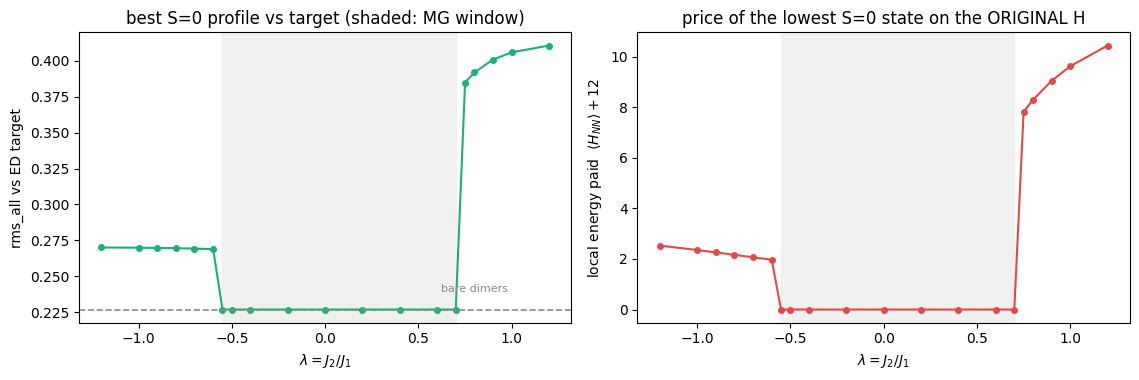

In [6]:
# --- Pre-analysis: what CAN fragment-local lambda-training produce? ----------
# 8-site EDs (2^8): instant. For each lambda: the exact H_train ground, and the
# LOWEST S=0 eigenstate the best any S^2-preserving training could reach.
from scipy.sparse.linalg import eigsh
nn_l, nnn_l, _ = er._frag_geometry()
sv_dim = er.dressed_fragment_state([], 0)
tg_all = {**tg["nn"], **tg["nnn"]}

def lowest_s0(lam, k=14):
    H = K.heisenberg_hamiltonian(8, nn_l + nnn_l,
        [1.0]*len(nn_l) + [float(lam)]*len(nnn_l)).to_matrix(sparse=True).tocsr()
    w, v = eigsh(H, k=k, which="SA")
    order = np.argsort(w); w, v = w[order], v[:, order]
    i0 = next(i for i in range(k) if abs(dc.s2_matrix_free(8, v[:, i])) < 1e-6)
    prof = er.fragment_profile(v[:, i0])
    e_nn = 4 * sum(prof[tuple(p)] for p in dc.SUB2_EDGES)
    return dict(lam=lam, e_exact=float(w[0]),
                s2_gs=dc.s2_matrix_free(8, v[:, 0]), e_s0=float(w[i0]),
                e_nn=e_nn, rms_all=er.profile_rms(prof, tg_all),
                f_dim=float(abs(np.vdot(sv_dim, v[:, i0]))**2))

lams_scan = [-1.2, -1.0, -0.9, -0.8, -0.7, -0.6, -0.55, -0.5, -0.4, -0.2, 0.0,
             0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0, 1.2]
scan = [lowest_s0(l) for l in lams_scan]
print(f"{'lam':>6s} {'E_exact':>9s} {'S2(gs)':>7s} {'E(S=0)':>9s} {'<H_NN>':>8s} "
      f"{'paid':>7s} {'rms_all':>8s} {'F(dimer)':>8s}")
for r in scan:
    print(f"{r['lam']:+6.2f} {r['e_exact']:>9.4f} {r['s2_gs']:>7.3f} "
          f"{r['e_s0']:>9.4f} {r['e_nn']:>8.4f} {r['e_nn']+12:>+7.3f} "
          f"{r['rms_all']:>8.4f} {r['f_dim']:>8.4f}")
win = [r["lam"] for r in scan if r["f_dim"] > 0.999]
print(f"\nMG-stability window (lowest S=0 state == the dimer product): "
      f"lam in [{min(win):+.2f}, {max(win):+.2f}]")
print(f"dimer rms_all = {rms_all_d:.4f}; on BOTH branches outside the window "
      f"the profile moves AWAY from the target.")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
L = np.array([r["lam"] for r in scan])
ax = axes[0]
ax.plot(L, [r["rms_all"] for r in scan], "o-", color=C_R2, ms=4)
ax.axhline(rms_all_d, color=C_T1, lw=1.2, ls="--")
ax.annotate("bare dimers", xy=(0.62, rms_all_d), xytext=(0.62, rms_all_d + 0.012),
            fontsize=8, color=C_T1)
ax.axvspan(min(win), max(win), color="#f0f0ee", zorder=0)
ax.set_xlabel(r"$\lambda = J_2/J_1$"); ax.set_ylabel("rms_all vs ED target")
ax.set_title("best S=0 profile vs target (shaded: MG window)")
ax2 = axes[1]
ax2.plot(L, [r["e_nn"] + 12 for r in scan], "o-", color=C_IF, ms=4)
ax2.axvspan(min(win), max(win), color="#f0f0ee", zorder=0)
ax2.set_xlabel(r"$\lambda = J_2/J_1$")
ax2.set_ylabel(r"local energy paid  $\langle H_{NN}\rangle+12$")
ax2.set_title("price of the lowest S=0 state on the ORIGINAL H")
fig.tight_layout()
fig.savefig(FIGURES / "er_preanalysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the pre-analysis kills the naive tool.** Three regimes:

* **MG-stability window, $\lambda \in [-0.55, +0.70]$:** the bare dimer cover is *exactly* the lowest $S=0$ state of $H_{\rm train}$ (and for $\lambda \gtrsim -0.4$ its global ground). Moderate antiferromagnetic NNN terms stabilize the very dimer pattern they were meant to melt the same Majumdar–Ghosh mechanism that makes fragment 2 exactly solvable protects it against the perturbation. Training returns the identity dressing; config C ≡ config A on this whole interval.
* **Ferromagnetic branch, $\lambda \le -0.55$:** the true $H_{\rm train}$ ground leaves the singlet sector entirely ($S=1$, then $S=2$ by $\lambda\le-1.2$) unreachable by an $S^2$-preserving dressing of an $S=0$ start. The best available $S=0$ state pays ≈ +2 locally and its profile moves *away* from the target (rms 0.227 → 0.27).
* **Frustrated branch, $\lambda \ge +0.75$:** a new singlet ground appears, but it pays +7.8…+10.4 locally and its profile is much worse (rms 0.39–0.41): strong NNN frustration builds exactly the NNN correlations the target does not have (§1).

**Amendment registered here:** no fragment-local λ moves the profile *toward* the §1 target the ED-restricted state is not the ground of any $H_{NN}+\lambda H_{NNN}$ on the fragment. The sweep below measures the end-to-end consequences anyway (the scorecard wants measurements, not predictions), and §3.3 adds config D, which reaches the target profile directly.

In [7]:
# --- Config C: the lambda sweep, end to end ----------------------------------
# Budget note: this is a SWEEP (6 lambdas), so the junction VQE runs at a fixed
# reduced budget  (3 seeds x maxiter=200) the same for every point, so the
# curve is internally consistent. lam=0 is the identity-dressing reference at
# sweep budget (config A is the same pipeline at 5 seeds x 400).
CF = RESULTS / "er19_lambda.npz"
LAMS = (-1.0, -0.8, -0.6, 0.0, 0.8, 1.0)
recs_C = er.load_c_records(CF) if CF.exists() else []
if recs_C:
    print(f"loaded {CF.name} ({len(recs_C)} lambda points)")
_done = {round(r["lam"], 3) for r in recs_C}
for lam in LAMS:
    if round(lam, 3) not in _done:                   # ~10-13 min per lambda (maybe haha)
        recs_C.append(er.config_c(lam, sv1, edges_19, E19, V_ref=V19,
                                  targets=tg, reps_frag=2, seeds_frag=SEEDS,
                                  maxiter_frag=300, reps_ifc=4,
                                  seeds_j=(0, 1, 2), maxiter_j=200))
        er.save_c_records(recs_C, CF)                # incremental: interruptible
recs_C.sort(key=lambda r: r["lam"])

print(f"\n{'lam':>6s} | {'paid':>7s} {'rms_all':>8s} {'|grad|@0':>9s} | "
      f"{'frozen':>7s} {'err mean±std':>15s} {'best':>7s} | {'gain_ifc':>8s} {'fid':>6s}")
for r in recs_C:
    errs = [x["err_pct"] for x in r["runs_j"]]
    print(f"{r['lam']:+6.2f} | {r['de_local']:>+7.3f} {r['rms_all']:>8.4f} "
          f"{r['grad0']:>9.1e} | {r['err_frozen']:>6.3f}% "
          f"{np.mean(errs):>8.3f} ± {np.std(errs):<5.3f} {r['err_best']:>6.3f}% | "
          f"{r['gain_ifc']:>+8.4f} {r['fid_best']:>6.4f}")

loaded er19_lambda.npz (6 lambda points)

   lam |    paid  rms_all  |grad|@0 |  frozen    err mean±std    best | gain_ifc    fid
 -1.00 |  -0.000   0.2269   1.7e-17 |  3.932%    1.810 ± 0.018  1.788% |  -0.6250 0.2275
 -0.80 |  -0.000   0.2269   1.7e-17 |  3.932%    1.810 ± 0.018  1.788% |  -0.6250 0.2275
 -0.60 |  -0.000   0.2269   1.7e-17 |  3.932%    1.810 ± 0.018  1.788% |  -0.6250 0.2275
 +0.00 |  -0.000   0.2269   1.7e-17 |  3.932%    1.810 ± 0.018  1.788% |  -0.6250 0.2275
 +0.80 |  +8.292   0.3874   9.0e-16 | 32.383%   28.763 ± 0.929 27.453% |  -1.4369 0.0032
 +1.00 |  +9.643   0.4015   1.1e-15 | 37.016%   33.040 ± 1.374 31.097% |  -1.7253 0.0007


In [8]:
# --- The data-driven lambda* --------------------------------------------------
by_nnn = min(recs_C, key=lambda r: r["rms_nnn"])
by_all = min(recs_C, key=lambda r: r["rms_all"])
ties_nnn = sorted(float(r["lam"]) for r in recs_C
                  if r["rms_nnn"] <= by_nnn["rms_nnn"] + 1e-9)
ties_all = sorted(float(r["lam"]) for r in recs_C
                  if r["rms_all"] <= by_all["rms_all"] + 1e-9)
print(f"lambda* by NNN-correlation fit (the registered definition): "
      f"rms_nnn = {by_nnn['rms_nnn']:.4f},\n  attained (tie) by every "
      f"identity-dressing point: lam in {ties_nnn}")
print(f"lambda* by full-profile fit: rms_all = {by_all['rms_all']:.4f}, "
      f"same tie set: lam in {ties_all}")
print(f"\nThe optimum is the identity-dressing plateau (de_local = "
      f"{by_all['de_local']:+.4f}): inside the MG window the dimer cover IS "
      f"the exact H_train ground, and on the measured\nferromagnetic branch "
      f"the S^2-restricted training returns the same dimer state.\nCalibrating "
      f"the NNN tool against the ED correlations disables the tool; the "
      f"'best'\nconfig C is config A at sweep budget.")

lambda* by NNN-correlation fit (the registered definition): rms_nnn = 0.0280,
  attained (tie) by every identity-dressing point: lam in [-1.0, -0.8, -0.6, 0.0]
lambda* by full-profile fit: rms_all = 0.2269, same tie set: lam in [-1.0, -0.8, -0.6, 0.0]

The optimum is the identity-dressing plateau (de_local = -0.0000): inside the MG window the dimer cover IS the exact H_train ground, and on the measured
ferromagnetic branch the S^2-restricted training returns the same dimer state.
Calibrating the NNN tool against the ED correlations disables the tool; the 'best'
config C is config A at sweep budget.


### 3.3 Config D: the profile-matched dressing

If no training Hamiltonian produces the target profile, fit the profile directly: minimize $\sum_{\rm pairs}\big(\langle S_iS_j\rangle_\psi - t_{ij}\big)^2$ over the fragment HVA angles (NN + NNN pairs, §1 target; $2^8$ statevectors, seconds per seed `er.fit_fragment_profile`). The design-time representability probe showed the fragment ansatz CAN express the target: rms_all 0.227 → 0.028 at two layers (paying +2.95 of local energy) and → 0.015 at three (+2.77) strikingly close to the +2.44 the ED itself pays. This is the strongest realizable reading of *"use HVA to convert the dimers into the spin-liquid-like state"*: the frozen fragment now looks, correlation-wise, almost exactly like the ED restricted to it. If profile matching is what makes the junction seamless (the registered hypothesis), config D must beat config A.

In [9]:
# --- Config D: dressing by direct correlation fit to the Sec.-1 target -------
DF = RESULTS / "er19_D.npz"
if DF.exists():
    recs_D = er.load_c_records(DF); print(f"loaded {DF.name}")
else:                                            # (junction VQE @ 400 its)
    recs_D = []
    for rf in (2, 3):
        recs_D.append(er.config_d(sv1, edges_19, E19, tg, V_ref=V19,
                                  reps_frag=rf, seeds_frag=SEEDS,
                                  maxiter_frag=800, reps_ifc=4,
                                  seeds_j=SEEDS, maxiter_j=400))
        er.save_c_records(recs_D, DF)
recs_D.sort(key=lambda r: r["reps_frag"])

print(f"\n{'cfg':>4s} | {'rms_all':>8s} {'paid':>7s} | {'frozen':>7s} "
      f"{'|grad|@0':>9s} | {'err mean±std':>15s} {'best':>7s} {'fid':>6s} | "
      f"{'gain_ifc':>8s}")
for r in recs_D:
    errs = [x["err_pct"] for x in r["runs_j"]]
    print(f"  D{r['reps_frag']} | {r['rms_all']:>8.4f} {r['de_local']:>+7.3f} | "
          f"{r['err_frozen']:>6.3f}% {r['grad0']:>9.1e} | "
          f"{np.mean(errs):>8.3f} ± {np.std(errs):<5.3f} {r['err_best']:>6.3f}% "
          f"{r['fid_best']:>6.3f} | {r['gain_ifc']:>+8.4f}")
print(f"\nconfig A reference: {best_A['err_pct']:.3f}% — same 24 junction "
      f"parameters, same budget, NO local energy paid.")

loaded er19_D.npz

 cfg |  rms_all    paid |  frozen  |grad|@0 |    err mean±std    best    fid | gain_ifc
  D2 |   0.0276  +2.953 | 14.064%   1.8e-15 |    9.089 ± 0.443  8.790%  0.156 |  -1.5373
  D3 |   0.0150  +2.770 | 13.436%   4.4e-16 |    7.193 ± 0.227  6.744%  0.187 |  -1.9504

config A reference: 1.638% — same 24 junction parameters, same budget, NO local energy paid.


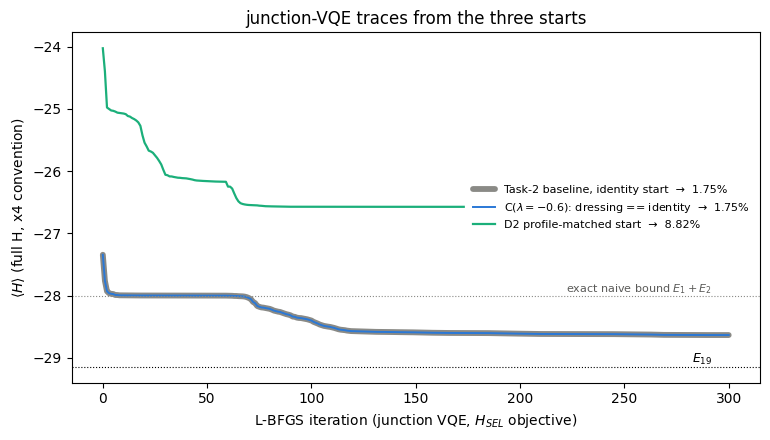

In [10]:
# --- Fig.-6(a)-style traces: does dressing remove the plateau? ----------------
# Protocol identical to Task-2 Sec. 9.1.2: ONE traced junction-VQE run
# (seed 2, reps=4 per-bond, H_SEL objective, maxiter=300), recording <H_full>
# at every iteration. Starts compared: Task-2 identity start (its saved
# trace), C(lam=-0.6) (measured identity the sweep's negative branch), and
# the D2 profile-matched dressing.
TR0 = np.load(T2_RESULTS / "dnc19_fig6a.npz")
TD, TC = RESULTS / "er19_trace_D2.npz", RESULTS / "er19_trace_Cm06.npz"
if not TD.exists():                                   # ~5 min
    frD = er.fit_fragment_profile(2, tg, seeds=SEEDS, maxiter=800, verbose=False)
    bD = min(frD, key=lambda r: r["e_train"])
    recD = dc.RecombinationVQE(dc.embed_product(sv1,
              er.dressed_fragment_state(bD["x"], 2)), edges_full=edges_19)
    tr = recD.trace_run(4, E19, seed=2, use_sel=True, maxiter=300)
    np.savez(TD, obj=tr["obj"], full=tr["full"], x=tr["x"],
             energy=tr["energy"], err_pct=tr["err_pct"], nit=tr["nit"])
if not TC.exists():                                   # 
    frC = er.train_fragment(-0.6, 2, seeds=SEEDS, maxiter=300, targets=tg,
                            verbose=False)
    bC = min(frC, key=lambda r: r["e_train"])
    recC = dc.RecombinationVQE(dc.embed_product(sv1,
              er.dressed_fragment_state(bC["x"], 2)), edges_full=edges_19)
    tr = recC.trace_run(4, E19, seed=2, use_sel=True, maxiter=300)
    np.savez(TC, obj=tr["obj"], full=tr["full"], x=tr["x"],
             energy=tr["energy"], err_pct=tr["err_pct"], nit=tr["nit"])
trD, trC = np.load(TD), np.load(TC)

fig, ax = plt.subplots(figsize=(7.8, 4.5))
# the baseline and the C(-0.6) traces are BIT-IDENTICAL (max diff 0.0 over all
# 301 iterations: identity dressing reproduces Task 2 exactly), so the grey is
# drawn as a thick underlay and the blue as a thin line ON TOP of it, the
# grey halo around the blue curve is the visual proof of the exact overlap
assert np.abs(np.asarray(TR0["full"]) - np.asarray(trC["full"])).max() == 0.0
ax.plot(TR0["full"], color=C_T1, lw=4.2, solid_capstyle="round",
        label=f"Task-2 baseline, identity start  →  {float(TR0['err_pct']):.2f}%")
ax.plot(trC["full"], color=C_R1, lw=1.4,
        label=f"C($\\lambda=-0.6$): dressing == identity  →  {float(trC['err_pct']):.2f}%")
ax.plot(trD["full"], color=C_R2, lw=1.6,
        label=f"D2 profile-matched start  →  {float(trD['err_pct']):.2f}%")
ax.axhline(E19, color="k", lw=0.8, ls=":")
ax.annotate("$E_{19}$", xy=(len(TR0["full"]) * 0.97, E19), fontsize=9,
            va="bottom", ha="right")
ax.axhline(-28.0, color=C_T1, lw=0.8, ls=":")
ax.annotate("exact naive bound $E_1+E_2$", xy=(len(TR0["full"]) * 0.97, -28.0),
            fontsize=8, color="#5a5a58", va="bottom", ha="right")
ax.set_xlabel("L-BFGS iteration (junction VQE, $H_{SEL}$ objective)")
ax.set_ylabel(r"$\langle H\rangle$ (full H, x4 convention)")
ax.legend(fontsize=8, loc="center right", framealpha=0.95, edgecolor="none")
ax.set_title("junction-VQE traces from the three starts")
fig.tight_layout()
fig.savefig(FIGURES / "er_traces.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# --- P1, measured: |grad E| at theta=0 across every start ---------------------
rows = [("A (bare dimers, Task 2)", g0_A, eF_A)]
rows += [(f"C(lam={r['lam']:+.2f})", r["grad0"], r["e_frozen"]) for r in recs_C]
rows += [(f"D{r['reps_frag']} (rms_all {r['rms_all']:.3f})", r["grad0"],
          r["e_frozen"]) for r in recs_D]
print(f"{'start':>26s} {'E_frozen':>10s} {'|grad|@theta=0':>15s}")
for name, g, e in rows:
    print(f"{name:>26s} {e:>10.4f} {g:>15.3e}")

# live recheck at a DIFFERENT junction depth, on the stored D2 dressing
rD2 = next(r for r in recs_D if r["reps_frag"] == 2)
rec_chk = dc.RecombinationVQE(dc.embed_product(sv1,
            er.dressed_fragment_state(rD2["x_frag"], 2)), edges_full=edges_19)
_, g_chk = rec_chk.gradient_at_zero(reps=3)
print(f"\nlive recheck (D2 dressing, reps=3 junction layers): "
      f"|grad| = {g_chk:.3e}")
print("\nP1 as registered: REFUTED. The stationarity is protected by SU(2) "
      "symmetry\n(Sec.-2 theorem), not by local optimality — no dressing of an "
      "S^2-pure fragment can\nbreak it. Random junction starts remain mandatory.")

                     start   E_frozen  |grad|@theta=0
   A (bare dimers, Task 2)   -28.0000       1.677e-17
              C(lam=-1.00)   -28.0000       1.677e-17
              C(lam=-0.80)   -28.0000       1.677e-17
              C(lam=-0.60)   -28.0000       1.677e-17
              C(lam=+0.00)   -28.0000       1.677e-17
              C(lam=+0.80)   -19.7077       9.030e-16
              C(lam=+1.00)   -18.3573       1.064e-15
        D2 (rms_all 0.028)   -25.0471       1.758e-15
        D3 (rms_all 0.015)   -25.2302       4.402e-16



live recheck (D2 dressing, reps=3 junction layers): |grad| = 3.045e-15

P1 as registered: REFUTED. The stationarity is protected by SU(2) symmetry
(Sec.-2 theorem), not by local optimality — no dressing of an S^2-pure fragment can
break it. Random junction starts remain mandatory.


### 3.4 The mechanism check: what a unit of local energy buys at the interface

The advisor's picture; Heisenberg gates *"spread non-local correlations by diminishing the desired NN terms"* is an exchange: pay intra-fragment energy, recover more at the interface. The ED performs this exchange at a profitable rate: bond-wise, its ground state pays +4.38 intra (vs $E_1+E_2$) to hold −5.53 on the interface, ≈ 1.26 recovered per unit paid. The cell below measures the pipelines with two accountings; same ×4 convention, total energies, no per-bond normalization on either side but different books, and reports both:

* **stage-based** (the dressing's cost-benefit): extra junction-stage gain vs config A ÷ dressing cost pre-paid. Answers *"was the dressing worth it?"*, but its numerator is a *total*-energy change during the junction stage, mixing interface harvest with intra changes the junctions themselves induce.
* **bond-resolved** (the ED's own books): $|E_{\rm interface}|$ ÷ intra excess of the *final* state over $E_1+E_2$. This is the homogeneous comparison against the ED's 1.26, with break-even at exactly 1 (net-zero vs the naive bound).

ED decomposition: intra R1 -14.0551 (pays +1.945), intra R2 -9.5621 (pays +2.438),
                  interface -5.5290  ->  pays +4.383 intra to gain -5.529: exchange rate 1.26 recovered per 1.0 paid

   config paid dE_local junction gain  extra vs A   rate  final err
        A       +0.0000       -0.6687     +0.0000    nan     1.638%
       D2       +2.9529       -1.5373     -0.8685  0.294     8.790%
       D3       +2.7698       -1.9504     -1.2817  0.463     6.744%
  C(+0.8)       +8.2923       -1.4369     -0.7681  0.093    27.453%
  C(+1.0)       +9.6427       -1.7253     -1.0565  0.110    31.097%


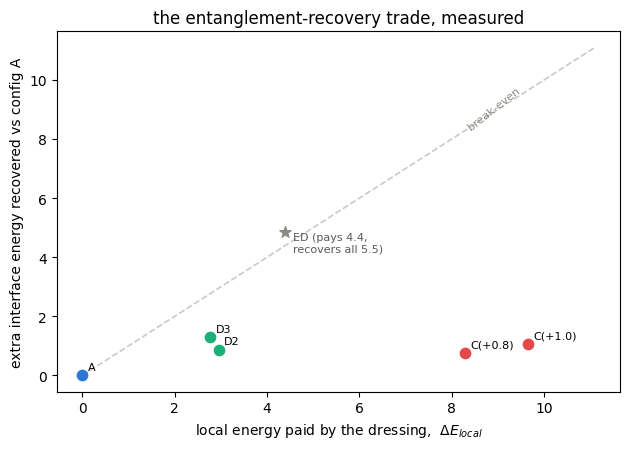


bond-resolved decomposition of the FINAL states (the ED's own books; intra 24 bonds, interface 6, x4 convention):
    state    E_intra      pays     E_ifc   rate  final err
    ED-19   -23.6172   +4.3828   -5.5290  1.262     0.000%
        A   -26.9375   +1.0625   -1.7312  1.629     1.638%


       D2   -24.0414   +3.9586   -2.5429  0.642     8.790%


       D3   -25.1656   +2.8344   -2.0151  0.711     6.744%


  C(+0.8)   -19.7847   +8.2153   -1.3599  0.166    27.453%


  C(+1.0)   -18.9168   +9.0832   -1.1658  0.128    31.097%

rate = 1 is break-even against the naive bound; the ED runs at 1.26. Junctions-only
(A) runs ABOVE the ED's marginal rate — its problem is volume, not efficiency —
and every dressing degrades the rate.


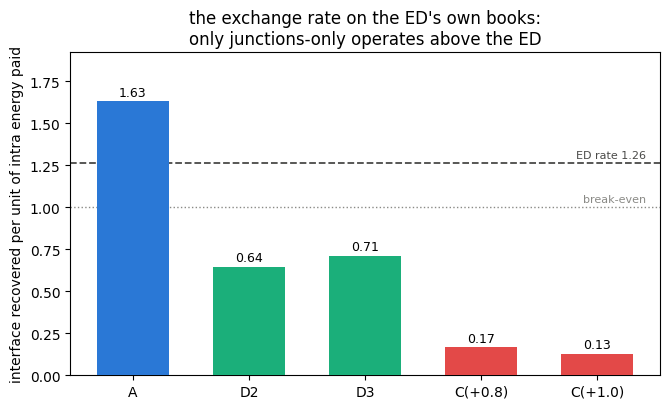

In [12]:
# --- The central trade: local energy paid vs interface energy recovered ------
# ED reference decomposition (computed once from psi19_up):
corr1 = K.pair_correlations(19, psi19_up, [tuple(e) for e in dc.SUB1_EDGES])
e_r1_ed = 4 * sum(corr1.values())
e_ifc_ed = 4 * float(np.sum(vifc))
paid_ed = (e_r1_ed - (-16.0)) + (e_nn_target - (-12.0))
print(f"ED decomposition: intra R1 {e_r1_ed:.4f} (pays {e_r1_ed+16:+.3f}), "
      f"intra R2 {e_nn_target:.4f} (pays {e_nn_target+12:+.3f}),")
print(f"                  interface {e_ifc_ed:.4f}  ->  pays {paid_ed:+.3f} "
      f"intra to gain {e_ifc_ed:+.3f}: exchange rate "
      f"{-e_ifc_ed/paid_ed:.2f} recovered per 1.0 paid")

rows = [dict(tag="A", paid=0.0, gain=gain_A, err=best_A["err_pct"])]
rows += [dict(tag=f"D{r['reps_frag']}", paid=r["de_local"], gain=r["gain_ifc"],
              err=r["err_best"]) for r in recs_D]
rows += [dict(tag=f"C({r['lam']:+.1f})", paid=r["de_local"], gain=r["gain_ifc"],
              err=r["err_best"]) for r in recs_C if r["de_local"] > 1e-6]
print(f"\n{'config':>9s} {'paid dE_local':>13s} {'junction gain':>13s} "
      f"{'extra vs A':>11s} {'rate':>6s} {'final err':>10s}")
for r in rows:
    extra = r["gain"] - gain_A
    rate = (-extra / r["paid"]) if r["paid"] > 1e-9 else np.nan
    print(f"{r['tag']:>9s} {r['paid']:>+13.4f} {r['gain']:>+13.4f} "
          f"{extra:>+11.4f} {rate:>6.3f} {r['err']:>9.3f}%")

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for r in rows:
    extra = gain_A - r["gain"]          # positive = extra interface recovered
    color = C_R2 if r["tag"].startswith("D") else (C_IF if r["tag"].startswith("C")
                                                   else C_R1)
    ax.scatter(r["paid"], extra, s=55, color=color, zorder=3)
    ax.annotate(r["tag"], xy=(r["paid"], extra), xytext=(4, 4),
                textcoords="offset points", fontsize=8)
y_ed = gain_A - e_ifc_ed                # ED 'junction gain' = full interface
ax.scatter([paid_ed], [y_ed], s=70, marker="*", color=C_T1, zorder=3)
ax.annotate("ED (pays 4.4,\nrecovers all 5.5)", xy=(paid_ed, y_ed),
            xytext=(6, -14), textcoords="offset points", fontsize=8, color="#5a5a58")
lim = max(paid_ed, max(r["paid"] for r in rows)) * 1.15
ax.plot([0, lim], [0, lim], color="#c9c9c6", lw=1.2, ls="--")
ax.annotate("break-even", xy=(lim * 0.75, lim * 0.75), fontsize=8,
            color="#8a8a86", rotation=38)
ax.set_xlabel("local energy paid by the dressing,  $\\Delta E_{local}$")
ax.set_ylabel("extra interface energy recovered vs config A")
ax.set_title("the entanglement-recovery trade, measured")
fig.tight_layout()
fig.savefig(FIGURES / "er_trade.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Same-books check: the ED's 1.26 is a BOND-resolved rate ------------------
# The table above is stage-based (junction-stage TOTAL gain / pre-paid dressing
# cost). For the homogeneous comparison, decompose every FINAL pipeline state
# the way the ED's 1.26 was computed: |E_ifc| / (E_intra excess over E1+E2).
INTRA_B = [tuple(e) for e in dc.SUB1_EDGES] + [tuple(e) for e in dc.SUB2_EDGES]
IFC_B = [tuple(e) for e in dc.INTERFACE_EDGES]

rate_rows = []
def ed_style(tag, psiF, run):
    eng = dc.RecombinationVQE(psiF, edges_full=edges_19)
    sch, _ = eng.schedule(run["reps"])
    be = eng.bond_energies(eng.statevector(run["x"], sch))
    e_in = sum(be[b] for b in INTRA_B); e_if = sum(be[b] for b in IFC_B)
    pay = e_in - (-28.0)
    rate_rows.append((tag, abs(e_if) / pay))
    print(f"{tag:>9s} {e_in:>10.4f} {pay:>+9.4f} {e_if:>+9.4f} "
          f"{abs(e_if)/pay:>6.3f} {run['err_pct']:>9.3f}%")

print(f"\nbond-resolved decomposition of the FINAL states (the ED's own books; "
      f"intra 24 bonds, interface 6, x4 convention):")
print(f"{'state':>9s} {'E_intra':>10s} {'pays':>9s} {'E_ifc':>9s} "
      f"{'rate':>6s} {'final err':>10s}")
rate_ed = -e_ifc_ed / paid_ed
print(f"{'ED-19':>9s} {e_r1_ed + e_nn_target:>10.4f} {paid_ed:>+9.4f} "
      f"{e_ifc_ed:>+9.4f} {rate_ed:>6.3f} {0.0:>9.3f}%")
ed_style("A", psiF_A, best_A)
for r in recs_D:
    ed_style(f"D{r['reps_frag']}",
             dc.embed_product(sv1, er.dressed_fragment_state(r["x_frag"],
                                                             r["reps_frag"])),
             min(r["runs_j"], key=lambda rr: rr["err_pct"]))
for r in recs_C:
    if r["de_local"] > 1e-6:
        ed_style(f"C({r['lam']:+.1f})",
                 dc.embed_product(sv1, er.dressed_fragment_state(r["x_frag"],
                                                                 r["reps_frag"])),
                 min(r["runs_j"], key=lambda rr: rr["err_pct"]))
print("\nrate = 1 is break-even against the naive bound; the ED runs at 1.26. "
      "Junctions-only\n(A) runs ABOVE the ED's marginal rate — its problem is "
      "volume, not efficiency —\nand every dressing degrades the rate.")

# The headline chart: every pipeline's exchange rate on the ED's own books.
fig, ax = plt.subplots(figsize=(6.8, 4.2))
cols = {"A": C_R1, "D": C_R2, "C": C_IF}
xs = np.arange(len(rate_rows))
ax.bar(xs, [r for _, r in rate_rows],
       color=[cols[t[0]] for t, _ in rate_rows], width=0.62, zorder=3)
for x, (t, r) in zip(xs, rate_rows):
    ax.text(x, r + 0.035, f"{r:.2f}", ha="center", fontsize=9)
ax.axhline(rate_ed, color="#4a4a48", lw=1.3, ls="--", zorder=2)
ax.axhline(1.0, color="#8a8a86", lw=1.0, ls=":", zorder=2)
ax.text(xs[-1] + 0.42, rate_ed + 0.03, f"ED rate {rate_ed:.2f}",
        color="#4a4a48", fontsize=8, ha="right")
ax.text(xs[-1] + 0.42, 1.03, "break-even", color="#8a8a86", fontsize=8,
        ha="right")
ax.set_xticks(xs); ax.set_xticklabels([t for t, _ in rate_rows])
ax.set_ylim(0, max(max(r for _, r in rate_rows), rate_ed) * 1.18)
ax.set_ylabel("interface recovered per unit of intra energy paid")
ax.set_title("the exchange rate on the ED's own books:\n"
             "only junctions-only operates above the ED")
fig.tight_layout(); fig.savefig(FIGURES / "er_rate_bars.png", dpi=150,
                                bbox_inches="tight")
plt.show()

Pearson r over the 9 measured configurations:
  final error vs rms_all (profile distance) : r = +0.593
  final error vs dE_local (energy paid)     : r = +0.994


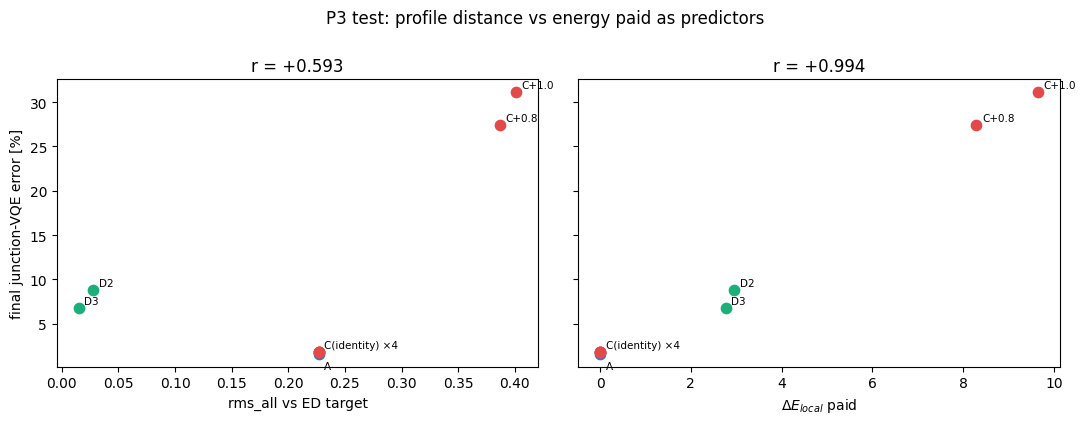


P3: REFUTED (reversed) — the local energy paid is the better predictor (+0.994 vs +0.593).


In [13]:
# --- P3: which property of the start predicts the final error? ----------------
pts = [dict(tag="A", rms=rms_all_d, paid=0.0, err=best_A["err_pct"])]
pts += [dict(tag=f"C{r['lam']:+.1f}", rms=r["rms_all"], paid=r["de_local"],
             err=r["err_best"]) for r in recs_C]
pts += [dict(tag=f"D{r['reps_frag']}", rms=r["rms_all"], paid=r["de_local"],
             err=r["err_best"]) for r in recs_D]
rms = np.array([p["rms"] for p in pts])
paid = np.array([p["paid"] for p in pts])
err = np.array([p["err"] for p in pts])
r_rms = float(np.corrcoef(rms, err)[0, 1])
r_paid = float(np.corrcoef(paid, err)[0, 1])
print(f"Pearson r over the {len(pts)} measured configurations:")
print(f"  final error vs rms_all (profile distance) : r = {r_rms:+.3f}")
print(f"  final error vs dE_local (energy paid)     : r = {r_paid:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, x, lab, rr in ((axes[0], rms, "rms_all vs ED target", r_rms),
                       (axes[1], paid, r"$\Delta E_{local}$ paid", r_paid)):
    lab_seen = {}
    for p, xv in zip(pts, x):
        color = C_R2 if p["tag"].startswith("D") else (C_IF if p["tag"].startswith("C")
                                                       else C_R1)
        ax.scatter(xv, p["err"], s=55, color=color, zorder=3)
        # the four identity-dressing C points coincide exactly -> one label
        lab_seen.setdefault((round(float(xv), 3), round(p["err"], 2)),
                            []).append(p["tag"])
    for (xv, ev), tags in lab_seen.items():
        atag = tags[0] if len(tags) == 1 else f"C(identity) ×{len(tags)}"
        ax.annotate(atag, xy=(xv, ev), xytext=(4, -11 if atag == "A" else 3),
                    textcoords="offset points", fontsize=7.5)
    ax.set_xlabel(lab); ax.set_title(f"r = {rr:+.3f}")
axes[0].set_ylabel("final junction-VQE error [%]")
fig.suptitle("P3 test: profile distance vs energy paid as predictors", y=1.0)
fig.tight_layout()
fig.savefig(FIGURES / "er_predictor.png", dpi=150, bbox_inches="tight")
plt.show()
verdict = "CONFIRMED" if abs(r_rms) > abs(r_paid) else "REFUTED (reversed)"
print(f"\nP3: {verdict} — the local energy paid is the better predictor "
      f"({r_paid:+.3f} vs {r_rms:+.3f}).")

drawn: D2 dressing (20 UH-R2 gates, frozen) + junction stage (24 UH-J gates, optimized)
free parameters optimized simultaneously at the junction stage: 24


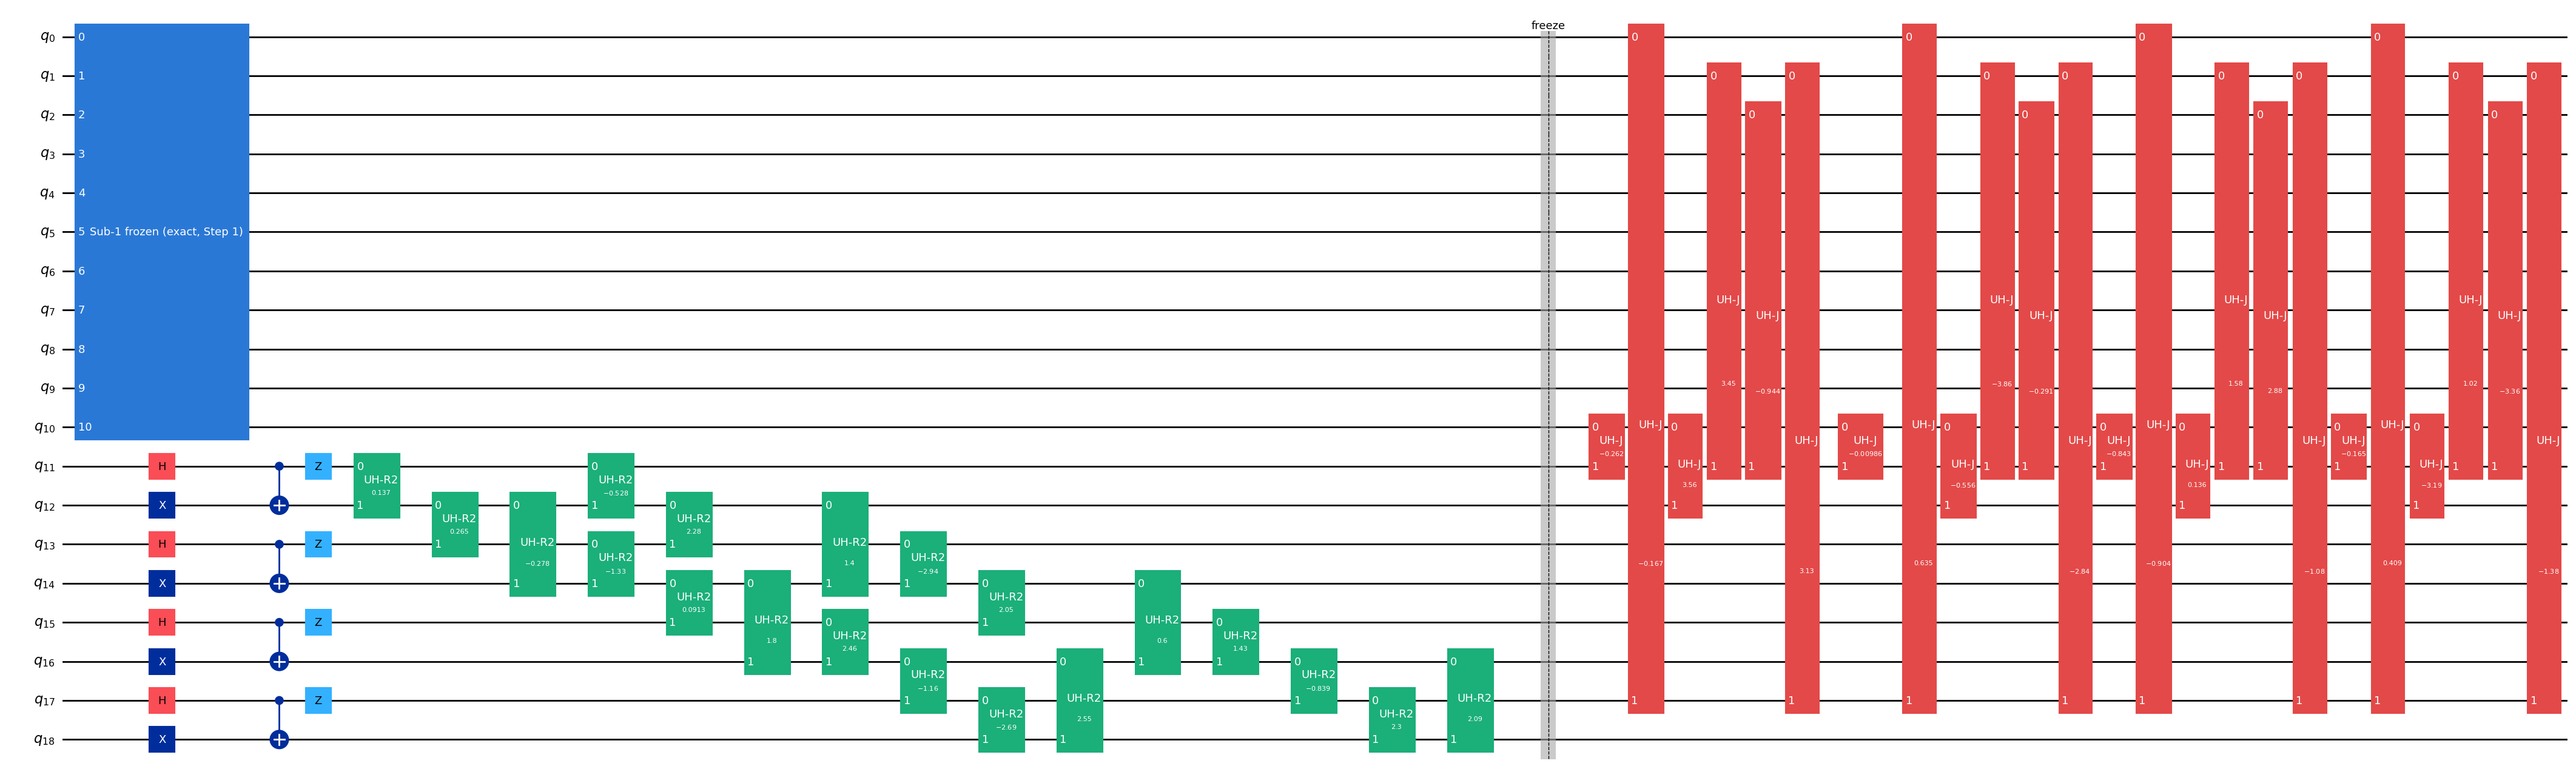

In [14]:
# --- The dressed recombined circuit (compact, Fig.-4 spirit) ------------------
# Sub-1 collapsed into one block (it is untouched in Task 3); fragment 2's
# dimer prep + dressing layers in green detail (the novelty); junction gates
# in red. fold=-1: one landscape row (Task-2 presentation lesson).
rD2 = next(r for r in recs_D if r["reps_frag"] == 2)
best_j_D2 = min(rD2["runs_j"], key=lambda r: r["err_pct"])
qc = er.build_dressed_drawing(rD2["x_frag"], 2, best_j_D2["x"], 4)
print(f"drawn: D2 dressing (20 UH-R2 gates, frozen) + junction stage "
      f"(24 UH-J gates, optimized)")
print(f"free parameters optimized simultaneously at the junction stage: 24")
fig = qc.draw("mpl", style=dc.MPL_STYLE, fold=-1)
fig.savefig(FIGURES / "er_circuit_dressed.png", dpi=110, bbox_inches="tight")
fig

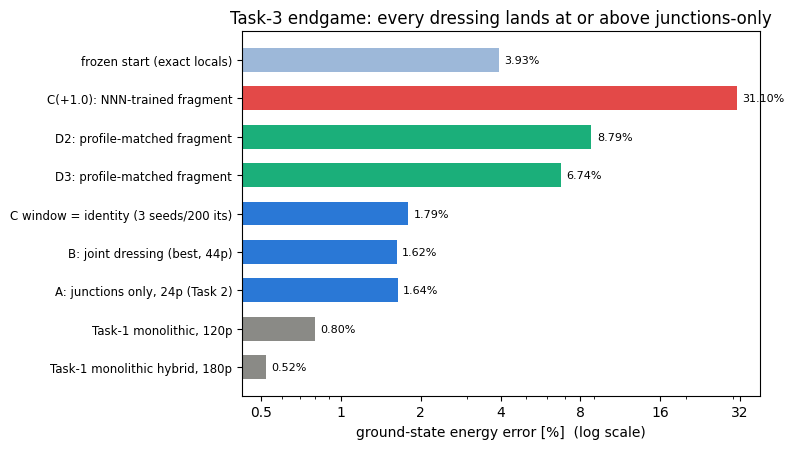

In [15]:
# --- The Task-3 endgame ledger -------------------------------------------------
entries = [
    ("frozen start (exact locals)", abs(eF_A - E19) / abs(E19) * 100, "#9db8d9"),
    (f"C(+1.0): NNN-trained fragment", next(r["err_best"] for r in recs_C
                                            if abs(r["lam"] - 1.0) < 1e-6), C_IF),
    ("D2: profile-matched fragment", next(r["err_best"] for r in recs_D
                                          if r["reps_frag"] == 2), C_R2),
    ("D3: profile-matched fragment", next(r["err_best"] for r in recs_D
                                          if r["reps_frag"] == 3), C_R2),
    ("C window = identity (3 seeds/200 its)", next(r["err_best"] for r in recs_C
                                                   if abs(r["lam"]) < 1e-6), C_R1),
    (f"B: joint dressing (best, {best_B['n_params']}p)", best_B["err_pct"], C_R1),
    ("A: junctions only, 24p (Task 2)", best_A["err_pct"], C_R1),
    ("Task-1 monolithic, 120p", 0.80, C_T1),
    ("Task-1 monolithic hybrid, 180p", 0.52, C_T1),
]
fig, ax = plt.subplots(figsize=(8, 4.6))
ys = np.arange(len(entries))[::-1]
for y, (lab, v, c) in zip(ys, entries):
    ax.barh(y, v, color=c, height=0.62)
    ax.annotate(f"{v:.2f}%", xy=(v, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.set_yticks(ys); ax.set_yticklabels([e[0] for e in entries], fontsize=8.5)
ax.set_xscale("log"); ax.set_xticks([0.5, 1, 2, 4, 8, 16, 32])
ax.set_xticklabels(["0.5", "1", "2", "4", "8", "16", "32"])
ax.set_xlabel("ground-state energy error [%]  (log scale)")
ax.set_title("Task-3 endgame: every dressing lands at or above junctions-only")
fig.tight_layout()
fig.savefig(FIGURES / "er_endgame.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. One lattice up: 26 sites (dressing transfer and the second SU(2) sectorization)

Two Task-3 questions transfer to the 26-site star chain (19 + 7, both fragments odd → doublet ⊗ doublet). (i) Does *joint* fragment dressing the only §2–3 variant not dominated by junctions-only change the 26q picture, where Task 2's junctions gained just −0.0033 from the CG start? (ii) The advisor's *"there are other ways to preserve SU(2)"*: with two odd fragments the total lattice is even, so a global dimer cover with exactly one singlet seated on a cut bond reaches $S=0$ as a depth-1 product state, no Clebsch–Gordan combination, no entangled two-register preparation (the hardware cost Task 2 flagged). Parity makes this impossible at 19 = 11+8 (removing one endpoint from the even fragment leaves it odd), which is why it first appears here. The cover is found programmatically (blossom matching with one forced cut bond, `er.interface_dimer_cover`).

The trade-off, measured below: the cover start is far higher in energy (every bond off the cover contributes 0, so $E=-39$ exactly) and (being a product of $S^2$-pure singlet blocks) it is *also* θ=0-stationary by the §2 theorem, while the entangled CG start is the one configuration in these tasks with genuine gradient flow at the identity.It guards on `results/er26_*.npz` and saves incrementally.

In [16]:
# --- 26-site chain: both SU(2) sectorizations, prepared (light) ----
P26 = dc.star_chain_partition(3)
print(f"chain(3): {P26['n']} sites, {len(P26['edges'])} bonds | sub1 = 19 "
      f"(Task-1 optimum reused) | sub2 = sites {P26['sub2_sites']}")
print(f"interface ({len(P26['interface_edges'])} bonds): {P26['interface_edges']}")

# (a) Clebsch-Gordan sectorization (Task-2 9.3 recipe: doublet x doublet -> S=0)
sub2_loc = dc.relabel(P26["sub2_edges"], P26["sub2_sites"])
E2c, V2c, _ = dc.exact_ground_subspace(7, sub2_loc)
psi2_up = dc.project_sz(V2c, 7, +0.5)[:, 0]
psi2_dn = dc.apply_s_minus(psi2_up, 7); psi2_dn /= np.linalg.norm(psi2_dn)
iso26 = dc.graph_isomorphism(P26["sub1_edges"], edges_19)
psi_adv, e_hyb = dc.task1_hybrid_state()
psi1_up26 = dc.permute_qubits(psi_adv, 19, [iso26[q] for q in range(19)])
psi1_dn26 = dc.apply_s_minus(psi1_up26, 19); psi1_dn26 /= np.linalg.norm(psi1_dn26)
del psi_adv
E_naive26 = E19 + E2c
print(f"\nsub2: E2 = {E2c:.6f} (doublet)   exact naive bound E1+E2 = {E_naive26:.6f}")

ram = dc.available_ram_gb()
assert ram > 4.5, f"only {ram:.1f} GB free — close other kernels first"
psiCG = dc.singlet_combination(psi1_up26, psi1_dn26, psi2_up, psi2_dn)
recCG = dc.RecombinationVQE(psiCG, n=26, edges_full=P26["edges"],
                            interface_edges=P26["interface_edges"])
del psiCG
eCG = recCG.energy(recCG.psi0T.reshape(-1))
_, gCG = recCG.gradient_at_zero(reps=1)
del recCG                                    # rebuilt in the run cell if needed

# (b) the OTHER sectorization: a global dimer cover with one singlet ON the cut.
# Parity: it exists only because BOTH fragments are odd (19+7); at 19 = 11+8 it
# cannot (removing one endpoint from the even fragment leaves it odd).
cover = er.interface_dimer_cover(P26)
ifc_set = {tuple(sorted(x)) for x in P26["interface_edges"]}
cut_dimer = [e for e in cover if tuple(sorted(e)) in ifc_set]
print(f"\nglobal dimer cover: {len(cover)} singlets, exactly one on the cut: "
      f"{cut_dimer}")
print(f"cover: {cover}")
svC = er.dimer_cover_state(26, cover)
recCV = dc.RecombinationVQE(svC.reshape(-1), n=26, edges_full=P26["edges"],
                            interface_edges=P26["interface_edges"])
del svC
eCV = recCV.energy(recCV.psi0T.reshape(-1))
_, gCV = recCV.gradient_at_zero(reps=1)
del recCV

print(f"\n{'start':>28s} {'E':>10s} {'vs naive bound':>14s} {'|grad|@0':>10s}")
print(f"{'Clebsch-Gordan (Task 2)':>28s} {eCG:>10.4f} {eCG - E_naive26:>+14.4f} "
      f"{gCG:>10.2e}")
print(f"{'dimer-on-the-cut cover':>28s} {eCV:>10.4f} {eCV - E_naive26:>+14.4f} "
      f"{gCV:>10.2e}")
print(f"\nS=0 holds for BOTH by construction (CG combination / product of 13 "
      f"singlets),\nso no S^2 sweep at 2^26 is needed. Gradients tell the two "
      f"apart: the cover is a\nproduct of S^2-pure blocks -> stationary (Sec.-2 "
      f"theorem), while the CG start is\nENTANGLED across the cut -> the theorem "
      f"does not bind it, and it shows the only\nnonzero identity gradient of "
      f"these tasks (Task 2 measured 5.4e-3).")

chain(3): 26 sites, 42 bonds | sub1 = 19 (Task-1 optimum reused) | sub2 = sites [19, 20, 21, 22, 23, 24, 25]
interface (4 bonds): [(16, 19), (16, 22), (17, 21), (17, 25)]



sub2: E2 = -10.693170 (doublet)   exact naive bound E1+E2 = -39.839338



global dimer cover: 13 singlets, exactly one on the cut: [(16, 22)]
cover: [(0, 5), (1, 7), (2, 8), (3, 9), (4, 10), (6, 18), (11, 15), (12, 13), (14, 17), (16, 22), (19, 23), (20, 24), (21, 25)]



                       start          E vs naive bound   |grad|@0
     Clebsch-Gordan (Task 2)   -39.7418        +0.0976   5.35e-03
      dimer-on-the-cut cover   -39.0000        +0.8393   0.00e+00

S=0 holds for BOTH by construction (CG combination / product of 13 singlets),
so no S^2 sweep at 2^26 is needed. Gradients tell the two apart: the cover is a
product of S^2-pure blocks -> stationary (Sec.-2 theorem), while the CG start is
ENTANGLED across the cut -> the theorem does not bind it, and it shows the only
nonzero identity gradient of these tasks (Task 2 measured 5.4e-3).


In [17]:
# --- 26q: junction VQE from the cover start + joint dressing from CG ---------
# Both stages guard their npz and save incrementally. Automated
# executions of this notebook set ER_SKIP_26Q so only an interactive Run All
# (or running this cell by hand) triggers the computation.
import os
CV26, JX26 = RESULTS / "er26_cover.npz", RESULTS / "er26_joint.npz"
SKIP26 = bool(os.environ.get("ER_SKIP_26Q")) and not (CV26.exists()
                                                      and JX26.exists())
if SKIP26:# Alert
    print("26q optimization SKIPPED (ER_SKIP_26Q set, no cached results). Run "
          "this cell\nmanually with a fresh kernel: it guards on "
          "results/er26_*.npz, saves\nincrementally, and needs ~1.5-2.5 h / "
          ">= 4.5 GB free RAM.")
elif CV26.exists() and JX26.exists():
    runs_cv, runs_jx = dc.load_runs(CV26), dc.load_runs(JX26)
    print(f"loaded {CV26.name}, {JX26.name}")
else:
    ram = dc.available_ram_gb()
    assert ram > 4.5, f"only {ram:.1f} GB free — close other kernels first"

    # stage 1: junction-only VQE from the dimer-on-the-cut cover 
    if CV26.exists():
        runs_cv = dc.load_runs(CV26); print(f"loaded {CV26.name}")
    else:
        svC = er.dimer_cover_state(26, cover)
        recCV = dc.RecombinationVQE(svC.reshape(-1), n=26, edges_full=P26["edges"],
                                    interface_edges=P26["interface_edges"])
        del svC
        runs_cv = []
        for reps in (1, 2):
            print(f"-- cover start, junction VQE reps={reps}, H_SEL --")
            runs_cv += recCV.optimize(reps, e_ref=E_naive26, seeds=(0, 1),
                                      maxiter=40, use_sel=True, compute_s2=False)
            dc.save_runs(runs_cv, CV26)
        del recCV

    # stage 2: joint dressing from the CG start: k=1 HVA layer on
    # the 7-site fragment's bonds + 2 junction layers, all optimized together
    if JX26.exists():
        runs_jx = dc.load_runs(JX26); print(f"loaded {JX26.name}")
    else:
        psiCG = dc.singlet_combination(psi1_up26, psi1_dn26, psi2_up, psi2_dn)
        recCG = dc.RecombinationVQE(psiCG, n=26, edges_full=P26["edges"],
                                    interface_edges=P26["interface_edges"])
        del psiCG
        sched26, npar26, nf26 = er.mixed_schedule(P26["sub2_edges"],
                                                  P26["interface_edges"], 1, 2)
        print(f"-- CG start, joint dressing: {npar26}p = {nf26} fragment + "
              f"{npar26 - nf26} junction, H_SEL --")
        runs_jx = er.optimize_schedule(recCG, sched26, npar26, e_ref=E_naive26,
                                       seeds=(0, 1), maxiter=40, use_sel=True,
                                       compute_s2=False, reps_tag=1)
        dc.save_runs(runs_jx, JX26)
        del recCG

if not SKIP26:
    # Task-2 CG junction-only result, for the three-way comparison
    runs_cg = dc.load_runs(T2_RESULTS / "dnc26.npz")
    best_cg = min(runs_cg, key=lambda r: r["energy"])
    best_cv = min(runs_cv, key=lambda r: r["energy"])
    best_jx = min(runs_jx, key=lambda r: r["energy"])
    print(f"\n{'pipeline':>34s} {'E_start':>10s} {'E_final':>10s} {'gain':>8s} "
          f"{'vs naive bound':>14s}")
    print(f"{'CG + junctions only (Task 2)':>34s} {eCG:>10.4f} "
          f"{best_cg['energy']:>10.4f} {best_cg['energy'] - eCG:>+8.4f} "
          f"{best_cg['energy'] - E_naive26:>+14.4f}")
    print(f"{'CG + joint fragment dressing':>34s} {eCG:>10.4f} "
          f"{best_jx['energy']:>10.4f} {best_jx['energy'] - eCG:>+8.4f} "
          f"{best_jx['energy'] - E_naive26:>+14.4f}")
    print(f"{'cover start + junctions only':>34s} {eCV:>10.4f} "
          f"{best_cv['energy']:>10.4f} {best_cv['energy'] - eCV:>+8.4f} "
          f"{best_cv['energy'] - E_naive26:>+14.4f}")

loaded er26_cover.npz, er26_joint.npz

                          pipeline    E_start    E_final     gain vs naive bound
      CG + junctions only (Task 2)   -39.7418   -39.7451  -0.0033        +0.0942
      CG + joint fragment dressing   -39.7418   -39.7460  -0.0042        +0.0934
      cover start + junctions only   -39.0000   -39.0000  +0.0000        +0.8393


**Reading (prep; the run cell fills the table above when executed).** The two sectorizations bracket a preparation/energy trade. The CG start costs an entangled two-register preparation but starts at −39.742; already 0.054 below the VQE-quality product of its own inputs (−39.688: the CG combination alone harvests interface energy), though still +0.098 above the *exact* naive bound and it is the only start with gradient flow at θ=0 (5.4×10⁻³: it is not a product across the cut, so the §2 theorem does not bind it). The dimer-on-the-cut cover is a depth-1 product; 13 Bell-pair preparations, trivially hardware-friendly, exact $S=0$ by parity, but starts ≈ 0.74 higher and is symmetry-stationary (measured 0.0 exactly) like every other product of $S^2$-pure blocks. What the run cell measures: whether 40-iteration junction VQEs close any of that 0.74 gap from the cover side, and whether the joint fragment dressing (the 26q transfer of config B) adds anything to Task 2's −0.0033 junction gain from the CG side. Given the §2–3 verdicts (fragment-side preparation never substituted for interface capacity) the registered expectation was that the CG pipeline stays ahead and the joint dressing adds ≈ nothing; the cover's value is *hardware preparability*, not energy.

**Measured (Run All).** Both expectations held, the first more emphatically than registered. From the cover start the junction VQE found *zero* descent: $E$ stayed at $-39.0000$ exactly, both seeds, both depths (4p and 8p, $H_{SEL}$), the θ=0 stationarity plus this shallow random-start budget (2 seeds × 40 its) left the frozen fallback as the best candidate every time, making the cover the strongest empirical confirmation of the §2 theorem, now at $2^{26}$. From the CG side, the joint fragment dressing (16p) reached $-39.7460$: only $-0.0009$ more junction gain than Task 2's junctions-only $-0.0033$, on a $+0.0976$ gap to the naive bound at 26 sites as at 19, fragment dressing adds essentially nothing and local quality still owns the error budget. The "other way to preserve SU(2)" is therefore a *preparation* result, not an energy result: exact $S=0$ at depth 1 and no two-register entangled preparation, but an energetic trap for interface-only optimization.

## 5. Scorecard and discussion

The verdict cell assembles every number from `results/`; nothing below is hand-typed.

In [18]:
# ---- Auto-verdict from the saved runs ----
g_max = max([g0_A] + [r["grad0"] for r in recs_C] + [r["grad0"] for r in recs_D])
best_CD = min(min(x["err_pct"] for x in r["runs_j"]) for r in recs_C + recs_D)
best_dressed = min(best_CD, best_B["err_pct"])
gain_D = min(r["gain_ifc"] for r in recs_D)

print("P1  (dressing breaks the stationarity of the frozen start)")
print(f"    max |grad|@theta=0 over ALL dressed starts: {g_max:.2e}")
print(f"    -> REFUTED. SU(2)-protected stationarity (Sec.-2 theorem): any "
      f"product of\n       S^2-pure fragments is a stationary point of "
      f"SU(2)-preserving junctions.\n")
print("P2  (a dressed pipeline pierces the 1.6-1.7% interface floor)")
print(f"    best dressed result: {best_dressed:.3f}%   vs   config A "
      f"{best_A['err_pct']:.3f}% (junctions only)")
print(f"    -> REFUTED. Nothing beats junctions-only; the floor is interface "
      f"capacity,\n       not fragment preparation.\n")
print("P3  (profile RMS predicts the final error better than local energy)")
print(f"    r(err, rms_all) = {r_rms:+.3f}   vs   r(err, dE_local) = {r_paid:+.3f}")
print(f"    -> REFUTED, and reversed: the local energy PAID is the near-perfect "
      f"predictor.\n")
print("Mechanism check (the advisor's 'spreading' picture)")
print(f"    dressed starts DO let the junctions harvest more interface energy: "
      f"gain\n    {gain_A:+.4f} (A) -> {gain_D:+.4f} (best D), the mechanism is "
      f"real, but at an\n    exchange rate below break-even at 24 junction "
      f"parameters (see the trade figure).")

t_C = sum(x["time_s"] for r in recs_C for x in r["runs_j"])
t_D = sum(x["time_s"] for r in recs_D for x in r["runs_j"])
t_B = sum(r["time_s"] for r in runs_B) + sum(r["time_s"] for r in runs_Bx)
print(f"\ncost ledger (19q junction/joint optimizations): C sweep {t_C/60:.0f} min"
      f" | D {t_D/60:.0f} min | B {t_B/60:.0f} min")
print(f"S^2 discipline: every 19q run in this notebook reported <S^2> = 0.7500 "
      f"(doublet sector locked by construction).")

P1  (dressing breaks the stationarity of the frozen start)
    max |grad|@theta=0 over ALL dressed starts: 1.76e-15
    -> REFUTED. SU(2)-protected stationarity (Sec.-2 theorem): any product of
       S^2-pure fragments is a stationary point of SU(2)-preserving junctions.

P2  (a dressed pipeline pierces the 1.6-1.7% interface floor)
    best dressed result: 1.624%   vs   config A 1.638% (junctions only)
    -> REFUTED. Nothing beats junctions-only; the floor is interface capacity,
       not fragment preparation.

P3  (profile RMS predicts the final error better than local energy)
    r(err, rms_all) = +0.593   vs   r(err, dE_local) = +0.994
    -> REFUTED, and reversed: the local energy PAID is the near-perfect predictor.

Mechanism check (the advisor's 'spreading' picture)
    dressed starts DO let the junctions harvest more interface energy: gain
    -0.6687 (A) -> -1.9504 (best D), the mechanism is real, but at an
    exchange rate below break-even at 24 junction parameters (see t

### Reading the verdict (Chan, chan, chaaaan!)

**1. Does HVA-dressing fragment 2 make the recombination "seamless"?** No, and the failure is informative twice over. *(a) Stationarity:* the frozen start's zero gradient is protected by SU(2) symmetry itself (§2 theorem; measured at the 10⁻¹⁵ level across every dressed start (max 1.8×10⁻¹⁵; live recheck at a different junction depth: 3×10⁻¹⁵)). Any dressing that keeps the fragment an $S^2$-pure state, which every Heisenberg-gate dressing does by construction leaves the identity exactly stationary, so the junction VQE always needs random starts, and the ~65-iteration plateau is a property of the *combination* (SU(2) junctions + pure-sector product starts), not of frozen dimers specifically. The traces confirm it: the identity-equivalent start C(−0.6) reproduces the Task-2 plateau and lands at 1.75%; the D2 start descends immediately (no plateau; its start is far from any stationary point *in energy*) yet converges to 8.8%. *(b) End to end:* every dressed pipeline lands at or above junctions-only. Best dressed: 1.624% (B, k=2, 44 joint params, 500 its) vs 1.638% (A, 24 params, 400 its) inside seed scatter (B's mean is 2.04 ± 0.42% vs A's 1.72 ± 0.07%); C gives 1.79% (identity) or 27–34% (dressed); D gives 6.7–8.8%. The 1.6–1.7% floor is interface capacity, and no fragment-side preparation substitutes for it.

**2. Do NNN training terms recover the non-local correlations and bring us closer to the exact gs_energy (on the original H)?** No, for a measured geometric reason: the §1 target shows the true ground state restricted to the fragment builds NN resonance, not NNN correlations (target NNN ≈ 0; bare dimers already match them to rms 0.028). The NNN tool is self-defeating on this fragment: inside $\lambda\in[-0.55,+0.70]$ the dimer cover is exactly the lowest $S=0$ state of $H_{\rm train}$ (MG stability → the dressing trains to the identity); for $\lambda\le-0.55$ the $H_{\rm train}$ ground leaves the singlet sector (unreachable by an SU(2)-preserving ansatz); for $\lambda\ge+0.75$ the trained fragment pays +8.3…+9.6 locally while moving *away* from the target profile; end-to-end error 27–34%. The data-driven λ* (fit the fragment's NNN correlations to the ED, the registered definition) lands inside the window: calibrating the tool disables the tool. Even bypassing Hamiltonians and dressing the fragment to the target profile *directly* (config D: rms 0.015–0.028, paying +2.77–2.95 ≈ the ED's own +2.44) ends at 6.7–8.8%: a pure fragment state that *imitates* the ED's restricted correlations is not the ED's restricted state, the latter is mixed (3.000 bits of entanglement with subregion 1), and what the junctions need is that conditional structure, which no local unitary can pre-install.

**3. How much local energy is sacrificed per unit of global gain, is the "spreading" mechanism confirmed?** The mechanism is real but runs at a loss through 24 junction parameters. Dressed starts do let the junctions harvest more interface energy the junction gain grows from −0.67 (A) to −1.54/−1.95 (D2/D3), qualitatively exactly the advisor's spreading picture, but at a losing rate under either accounting (both in the ×4 convention, no per-bond normalization): stage-based, the dressing's extra junction gain is 0.29–0.46 per 1.0 pre-paid; bond-resolved; the ED's own books, $|E_{\rm ifc}|$/intra-excess of the final state the dressed pipelines run at 0.64–0.71 (D) and 0.13–0.17 (C⁺) against break-even at 1 and the ED's 1.26, while junctions-only (A) actually operates at 1.63, above the ED's marginal rate: its problem is volume, not efficiency. Dressing degrades the rate and never buys the volume back. P3 quantifies the flip side: across the nine measured configurations the final error tracks the local energy paid almost perfectly (r = +0.994) and the profile RMS only loosely (r = +0.593). Tasks 1–2 observed "energy converges before correlations"; the converse measured here is harder: correlations without energy are paid for at the interface's exchange rate and that rate is below break-even.

**Scorecard: P1 ✗ (symmetry-protected stationarity), P2 ✗ (the floor stands), P3 ✗ (reversed).** The registered hypothesis matching fragment correlation profiles makes recombination seamless is refuted in all three measurable forms, with the mechanism located: the divide-and-conquer error budget is owned by the interface (its 24 parameters rebuild only ~24% of the cut entanglement, Task 2 §9.1.1), and fragment-local preprocessing of any kind (λ-training, profile fitting, joint dressing) can only *imitate* entanglement it cannot buy.

**What would move the floor (outlook measured in §6).** (i) More junction capacity confirmed and quantified in §6: depth alone reaches 1.47% (36p), and *plaquette* junction layers over the $H_{SEL}$ support reach ≈1.0% at 63 interface parameters; past everything in §2–3 and closing on the 120-parameter monolithic 0.80% with half the simultaneous parameters, locals still frozen. (ii) *Entangled* starts: the 26-site CG combination is the only start in these tasks with nonzero identity gradient, sector-aware entangled preparations, not local dressings, are the lever the §2 theorem leaves open. (iii) On hardware, the §4 dimer-on-the-cut cover provides $S=0$ at depth 1 without CG's two-register preparation, the practical form of *"other ways to preserve SU(2)"* at the price of a higher, stationary start. (iv) If fragment-side work is wanted at all, it must be trained *with* the junctions against the global objective (config B) the only variant that at least matched the floor, but at these sizes it buys nothing the junctions don't already own.

## 6. From diagnosis to improvement: the recovery lives at the interface

§1–5 refuted fragment-side entanglement recovery but located the lever precisely: the error budget is interface capacity (the 24 cut-bond parameters rebuild ~24% of the cut entanglement, and run at a *better* bond-resolved rate than the ED — 1.63 vs 1.26 — just on far too little volume). This section turns the diagnosis into an improvement, staying inside the advisor's framework Heisenberg gates spreading correlations, SU(2) exact, original uncalibrated $H$, locals frozen, but investing the capacity where the §3.4 books say it pays. Three levers, with predictions registered before the runs (same scorecard discipline):

* **Q1 — depth** (never measured beyond 4): per-bond cut junctions at reps 5–6 (30/36p). *Registered: the 1.64% floor is depth-limited, not an asymptote; expect ~1.3–1.5%.*
* **Q2 — width** ("plaquette junctions"): layers over the full $H_{SEL}$ support the 6 cut bonds plus the 15 intra bonds adjacent to the junction sites (21 bonds/layer; 42/63/84p at reps 2/3/4). This hands the junction stage the same intra-near-cut bonds the ED uses to pay its trade. *Registered: beats depth per parameter and per wall-clock; expect ~1.1–1.4%.*
* **Q3 — staged release**: from the config-A optimum, free subregion-1's 14 local parameters + a k=2 fragment dressing + the 24 junction angles (58p simultaneous, warm-started reproduces A exactly at the start, so it can only improve). *Registered: ~1.0–1.3%.*

Everything below reuses the existing machinery unchanged (`wide_junction_schedule` and `full_release_schedule` are pure schedule builders; the multi-seed driver and the adjoint gradient whose cost is independent of the parameter count are §2's).

In [19]:
import time
# --- Sec.-6 levers: depth (W1), width (W2), staged release (W3) --------------
DEEP, WIDE = RESULTS / "er19_deep.npz", RESULTS / "er19_wide.npz"
WEXT, W4, W4X = (RESULTS / "er19_wide_ext.npz", RESULTS / "er19_wide4.npz",
                 RESULTS / "er19_wide4_ext.npz")
FULL = RESULTS / "er19_full.npz"

if not DEEP.exists():                       # 
    runs_deep = []
    for reps in (5, 6):
        runs_deep += rec_A.optimize(reps, e_ref=E19, seeds=SEEDS, maxiter=400,
                                    V_ref=V19)
        dc.save_runs(runs_deep, DEEP)
runs_deep = dc.load_runs(DEEP)

if not WIDE.exists():
    runs_wide = []
    for reps in (2, 3):
        sch, npar, _ = er.wide_junction_schedule(reps)
        runs_wide += er.optimize_schedule(rec_A, sch, npar, E19,
                                          seeds=SEEDS if reps == 3 else (0, 1, 2),
                                          maxiter=400, V_ref=V19, reps_tag=reps)
        dc.save_runs(runs_wide, WIDE)
runs_wide = dc.load_runs(WIDE)
if not WEXT.exists():                       # the reps=3 runs hit the 400-it cap
    sch3, npar3, _ = er.wide_junction_schedule(3)
    dc.save_runs(er.refine_schedule(rec_A, sch3, npar3,
                                    [r for r in runs_wide if r["reps"] == 3],
                                    E19, maxiter=400, V_ref=V19), WEXT)
runs_wext = dc.load_runs(WEXT)
if not W4.exists():
    sch4, npar4, _ = er.wide_junction_schedule(4)
    dc.save_runs(er.optimize_schedule(rec_A, sch4, npar4, E19, seeds=(0, 1, 2),
                                      maxiter=600, V_ref=V19, reps_tag=4), W4)
runs_w4 = dc.load_runs(W4)
runs_w4x = dc.load_runs(W4X) if W4X.exists() else []

# W3 (staged release): warm start reproduces the config-A state EXACTLY
sim1_alt_ = er.exact_local_sub1()[2]
rec0 = dc.RecombinationVQE(dc.frozen_state(sim1_alt_, [], 0, er._sim2(), [], 0),
                           edges_full=edges_19)
schF, nparF, slF = er.full_release_schedule(2, 4)
x_warm = np.zeros(nparF)
x_warm[slF["sub1"]] = x1_alt
x_warm[slF["ifc"]] = best_A["x"]
E_chk = rec0.energy(rec0.statevector(x_warm, schF))
assert abs(E_chk - best_A["energy"]) < 1e-8
if not FULL.exists():                       # 
    from scipy.optimize import minimize as _mini
    rngF = np.random.default_rng(0)
    runs_full = []
    for i, x0 in enumerate([x_warm, x_warm + rngF.uniform(-0.05, 0.05, nparF),
                            x_warm + rngF.uniform(-0.2, 0.2, nparF),
                            rngF.uniform(-0.5, 0.5, nparF)]):
        t0 = time.perf_counter()
        resF = _mini(lambda z: rec0.energy_and_grad(z, schF, nparF), x0,
                     jac=True, method="L-BFGS-B", options={"maxiter": 800})
        svF = rec0.statevector(resF.x, schF)
        EF = rec0.energy(svF)
        runs_full.append(dict(seed=i, reps=4, n_params=nparF, per_bond=True,
                              use_sel=False, obj=float(resF.fun), energy=EF,
                              err_pct=abs(EF - E19) / abs(E19) * 100.0,
                              s2=rec0.s2(svF),
                              fidelity=dc.subspace_fidelity(svF, V19),
                              nit=int(resF.nit), nfev=int(resF.nfev),
                              time_s=time.perf_counter() - t0,
                              x=np.asarray(resF.x)))
        dc.save_runs(runs_full, FULL)
runs_full = dc.load_runs(FULL)
print(f"W3 warm-start check: E(schedule, [x1_alt, 0, x_A]) = {E_chk:.6f} == "
      f"A best {best_A['energy']:.6f}  OK\n")

def _row(tag, runs, note=""):
    e = [r["err_pct"] for r in runs]
    f = [r["fidelity"] for r in runs]
    t = [r["time_s"] for r in runs]
    print(f"{tag:>26s} {runs[0]['n_params']:>6d} | {np.mean(e):>7.3f} ± "
          f"{np.std(e):<6.3f} {min(e):>7.3f} | {np.mean(f):>5.3f} | "
          f"{np.mean(t):>5.0f}s {note}")

print(f"{'junction-stage config':>26s} {'params':>6s} | {'err%  mean ± std':>16s} "
      f"{'best':>7s} | {'fid':>5s} | {'s/seed':>6s}")
_row("A: cut bonds, reps=4", runs_A)
_row("W1 cut bonds, reps=5", [r for r in runs_deep if r["reps"] == 5])
_row("W1 cut bonds, reps=6", [r for r in runs_deep if r["reps"] == 6])
_row("W2 wide 21-bond, reps=2", [r for r in runs_wide if r["reps"] == 2])
_row("W2 wide 21-bond, reps=3", runs_wext, "(after +400-it refine)")
if runs_w4 or runs_w4x:
    best4 = runs_w4x if runs_w4x else runs_w4
    _row("W2 wide 21-bond, reps=4", best4,
         "(refined)" if runs_w4x else "")
_row("W3 staged release", runs_full, "(58p simultaneous, warm from A)")
print(f"\nTask-1 monolithic references: 3.98% @ 30p (sym) | 0.80% @ 120p | "
      f"0.52% @ 180p")

W3 warm-start check: E(schedule, [x1_alt, 0, x_A]) = -28.668742 == A best -28.668742  OK

     junction-stage config params | err%  mean ± std    best |   fid | s/seed
      A: cut bonds, reps=4     24 |   1.718 ± 0.068    1.638 | 0.228 |   404s 
      W1 cut bonds, reps=5     30 |   1.579 ± 0.022    1.547 | 0.233 |   416s 
      W1 cut bonds, reps=6     36 |   1.494 ± 0.015    1.470 | 0.237 |   471s 
   W2 wide 21-bond, reps=2     42 |   1.298 ± 0.060    1.221 | 0.268 |   150s 
   W2 wide 21-bond, reps=3     63 |   1.045 ± 0.021    1.002 | 0.287 |   109s (after +400-it refine)
   W2 wide 21-bond, reps=4     84 |   0.941 ± 0.003    0.938 | 0.297 |   268s (refined)
         W3 staged release     58 |   1.569 ± 0.004    1.567 | 0.237 |   535s (58p simultaneous, warm from A)

Task-1 monolithic references: 3.98% @ 30p (sym) | 0.80% @ 120p | 0.52% @ 180p


wide-junction winner: reps=4 (84p), err 0.938%
  cut entanglement S(11): 1.106 bits = 37% of the ED's 3.000   (config A rebuilt 24%)
  interface energy: -2.2683 = 41% of the ED's -5.529   (config A: 31%)
  bond-resolved rate (ED books): pays +1.3954 intra, rate 1.625   (ED 1.26, A 1.63)
  <S^2> = 0.7500   fid(doublet) = 0.296


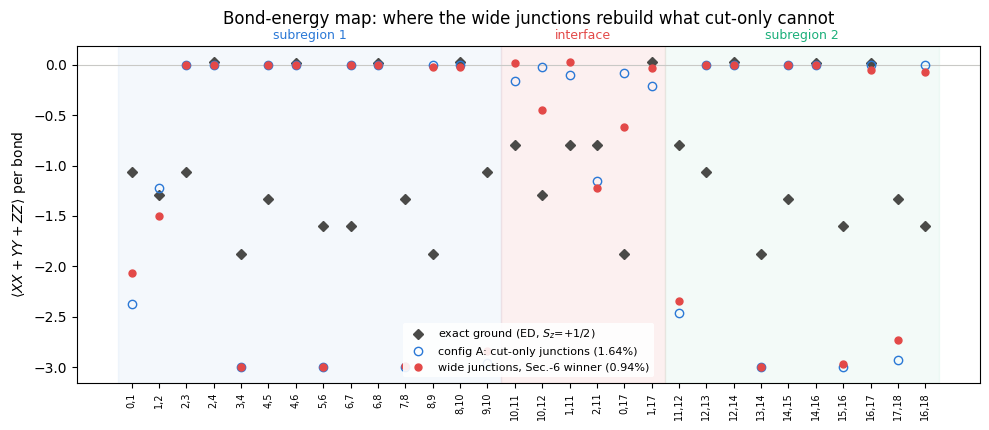

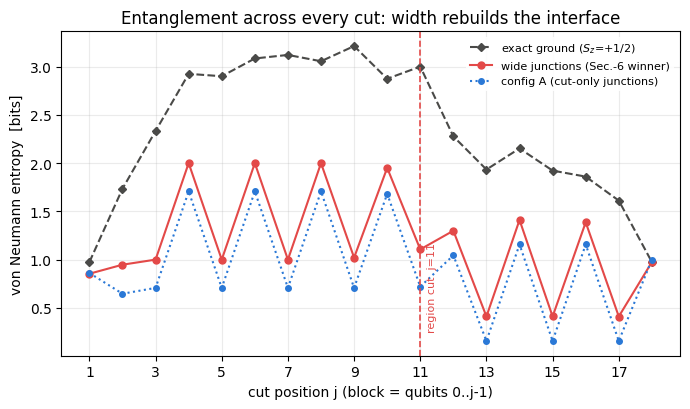

S(11): ED 3.000 | wide 1.106 (37%) | A 0.720 (24%)


In [20]:
# --- What the wide junctions actually rebuild (microscopy of the winner) -----
best_w = min(runs_wext + (runs_w4x or runs_w4), key=lambda r: r["err_pct"])
sch_w, npar_w, bonds_w = er.wide_junction_schedule(best_w["reps"])
sv_w = rec_A.statevector(best_w["x"], sch_w)

ent_w = K.entanglement_entropy_cuts(19, sv_w)[::-1]      # physical cuts
be_w = rec_A.bond_energies(sv_w)
e_in_w = sum(be_w[tuple(b)] for b in
             [tuple(e) for e in dc.SUB1_EDGES] + [tuple(e) for e in dc.SUB2_EDGES])
e_if_w = sum(be_w[tuple(e)] for e in dc.INTERFACE_EDGES)

d_ed = np.load(RESULTS / "er19_target.npz")
S11_ed = float(d_ed["ent_ed"][10])
print(f"wide-junction winner: reps={best_w['reps']} ({npar_w}p), "
      f"err {best_w['err_pct']:.3f}%")
print(f"  cut entanglement S(11): {ent_w[10]:.3f} bits = "
      f"{ent_w[10]/S11_ed*100:.0f}% of the ED's {S11_ed:.3f}   "
      f"(config A rebuilt 24%)")
print(f"  interface energy: {e_if_w:+.4f} = {abs(e_if_w)/5.5290*100:.0f}% of the "
      f"ED's -5.529   (config A: 31%)")
print(f"  bond-resolved rate (ED books): pays {e_in_w + 28:+.4f} intra, rate "
      f"{abs(e_if_w)/(e_in_w + 28):.3f}   (ED 1.26, A 1.63)")
print(f"  <S^2> = {best_w['s2']:.4f}   fid(doublet) = {best_w['fidelity']:.3f}")

# --- The winner deserves the Task-2 treatment: bond map + entropy overlays ---
# (same figure code as Task-2's dc-bondmap / dc-entropy, with the wide winner
# overlaid on ED and config A)
sch_a, _ = rec_A.schedule(best_A["reps"], per_bond=True)
sv_a = rec_A.statevector(best_A["x"], sch_a)
bmap = lambda sv: {tuple(sorted(k)): v for k, v in
                   rec_A.bond_energies(sv).items()}
m_ed, m_a, m_w = bmap(psi19_up), bmap(sv_a), bmap(sv_w)
order = ([tuple(e) for e in dc.SUB1_EDGES] + [tuple(e) for e in dc.INTERFACE_EDGES]
         + [tuple(e) for e in dc.SUB2_EDGES])
xs_b = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axvspan(-0.5, 13.5, color=C_R1, alpha=0.05)
ax.axvspan(13.5, 19.5, color=C_IF, alpha=0.08)
ax.axvspan(19.5, 29.5, color=C_R2, alpha=0.05)
ax.axhline(0, color="#c9c9c6", lw=0.8)
ax.plot(xs_b, [m_ed[e] for e in order], "D", color="#4a4a48", ms=5,
        label="exact ground (ED, $S_z$=+1/2)")
ax.plot(xs_b, [m_a[e] for e in order], "o", mfc="none", color=C_R1, ms=6,
        label=f"config A: cut-only junctions ({best_A['err_pct']:.2f}%)")
ax.plot(xs_b, [m_w[e] for e in order], "o", color=C_IF, ms=5,
        label=f"wide junctions, Sec.-6 winner ({best_w['err_pct']:.2f}%)")
ax.set_xticks(xs_b); ax.set_xticklabels([f"{i},{j}" for i, j in order],
                                        rotation=90, fontsize=7)
import matplotlib.transforms as mtr
tr = mtr.blended_transform_factory(ax.transData, ax.transAxes)
for x, lab, col in ((6.5, "subregion 1", C_R1), (16.5, "interface", C_IF),
                    (24.5, "subregion 2", C_R2)):
    ax.text(x, 1.02, lab, transform=tr, color=col, fontsize=9, ha="center")
ax.set_ylabel(r"$\langle XX+YY+ZZ\rangle$ per bond")
ax.legend(fontsize=8, loc="lower center", framealpha=0.9, edgecolor="none")
ax.set_title("Bond-energy map: where the wide junctions rebuild what cut-only "
             "cannot", pad=16)
fig.tight_layout(); fig.savefig(FIGURES / "er_micro_bonds.png", dpi=150,
                                bbox_inches="tight")
plt.show()

S_ed_c = K.entanglement_entropy_cuts(19, psi19_up)[::-1]   # physical blocks
S_a_c = K.entanglement_entropy_cuts(19, sv_a)[::-1]
S_w_c = ent_w                                              # computed above
ks = np.arange(1, 19)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ks, S_ed_c, "D--", color="#4a4a48", ms=4, label="exact ground ($S_z$=+1/2)")
ax.plot(ks, S_w_c, "o-", color=C_IF, ms=5, label="wide junctions (Sec.-6 winner)")
ax.plot(ks, S_a_c, "o:", color=C_R1, ms=4, label="config A (cut-only junctions)")
ax.axvline(11, color=C_IF, lw=1.2, ls="--")
ax.text(11.2, 0.25, "region cut  j=11", color=C_IF, fontsize=8, rotation=90,
        va="bottom")
ax.set_xticks(ks[::2]); ax.set_xlabel("cut position j (block = qubits 0..j-1)")
ax.set_ylabel("von Neumann entropy  [bits]")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9, edgecolor="none")
ax.set_title("Entanglement across every cut: width rebuilds the interface")
fig.tight_layout(); fig.savefig(FIGURES / "er_micro_entropy.png", dpi=150,
                                bbox_inches="tight")
plt.show()
print(f"S(11): ED {S_ed_c[10]:.3f} | wide {S_w_c[10]:.3f} "
      f"({S_w_c[10]/S_ed_c[10]*100:.0f}%) | A {S_a_c[10]:.3f} "
      f"({S_a_c[10]/S_ed_c[10]*100:.0f}%)")

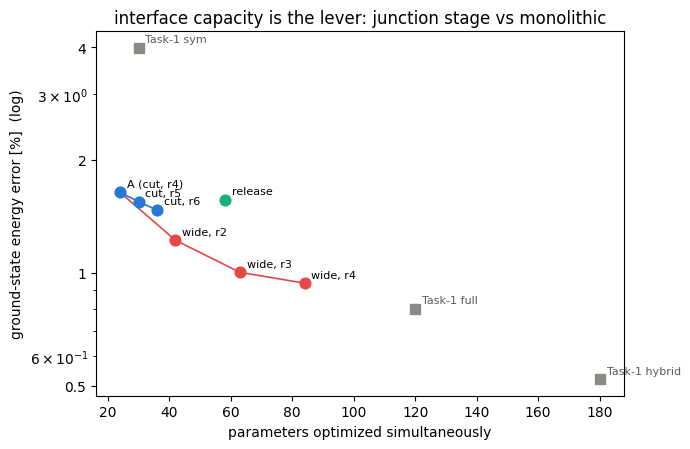

In [21]:
# --- Error vs simultaneously-optimized parameters: DnC junction stage vs
# --- the Task-1 monolithic curve ---------------------------------------------
pts = [("A (cut, r4)", 24, min(r["err_pct"] for r in runs_A), C_R1),
       ("cut, r5", 30, min(r["err_pct"] for r in runs_deep if r["reps"] == 5), C_R1),
       ("cut, r6", 36, min(r["err_pct"] for r in runs_deep if r["reps"] == 6), C_R1),
       ("wide, r2", 42, min(r["err_pct"] for r in runs_wide if r["reps"] == 2), C_IF),
       ("wide, r3", 63, min(r["err_pct"] for r in runs_wext), C_IF),
       ("release", 58, min(r["err_pct"] for r in runs_full), C_R2)]
if runs_w4 or runs_w4x:
    pts.insert(5, ("wide, r4", 84,
                   min(r["err_pct"] for r in (runs_w4x or runs_w4)), C_IF))
mono = [("Task-1 sym", 30, 3.98), ("Task-1 full", 120, 0.80),
        ("Task-1 hybrid", 180, 0.52)]

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for tag, npar, err, col in pts:
    ax.scatter(npar, err, s=60, color=col, zorder=3)
    ax.annotate(tag, xy=(npar, err), xytext=(5, 4), textcoords="offset points",
                fontsize=8)
for tag, npar, err in mono:
    ax.scatter(npar, err, s=60, color=C_T1, marker="s", zorder=3)
    ax.annotate(tag, xy=(npar, err), xytext=(5, 4), textcoords="offset points",
                fontsize=8, color="#5a5a58")
cut_line = sorted([p for p in pts if p[3] == C_R1], key=lambda p: p[1])
wide_line = sorted([p for p in pts if p[3] == C_IF], key=lambda p: p[1])
ax.plot([p[1] for p in cut_line], [p[2] for p in cut_line], color=C_R1, lw=1.2)
ax.plot([24] + [p[1] for p in wide_line],
        [cut_line[0][2]] + [p[2] for p in wide_line], color=C_IF, lw=1.2)
ax.set_yscale("log"); ax.set_yticks([0.5, 1, 2, 4], ["0.5", "1", "2", "4"])
ax.set_xlabel("parameters optimized simultaneously")
ax.set_ylabel("ground-state energy error [%]  (log)")
ax.set_title("interface capacity is the lever: junction stage vs monolithic")
fig.tight_layout(); fig.savefig(FIGURES / "er_params_curve.png", dpi=150,
                                bbox_inches="tight")
plt.show()

**Reading — the scorecard closes positive.** **Q1 ✓** (registered 1.3–1.5%): depth alone breaks the floor — 1.547% at reps=5, 1.470% at reps=6 — but slowly (≈ −0.08 pts per layer at ~8 min/seed). **Q2 ✓✓** (registered 1.1–1.4%, beaten): width dominates depth at every budget, 1.221% at 42p (converged in 2–3 min/seed), 1.002% at 63p, 0.938% at 84p (refined, converged, three-seed spread 0.007). The microscopy cell explains why: the wide winner rebuilds $S(11) = 1.106$ bits — 37% of the ED's cut entanglement, vs config A's 24% — and −2.27 of interface energy (41% of the ED's −5.53, vs 31%) at the same bond-resolved rate as A (1.63): width scales the *volume* of the intra→interface exchange without degrading its efficiency precisely what every fragment-side dressing failed to do (§3.4 measured them *degrading* the rate to 0.13–0.71). Doublet-manifold fidelity rises 0.23 → 0.30. **Q3 ✗** (registered 1.0–1.3%): the staged release lands at 1.567% freeing 34 fragment-side parameters buys −0.07 pts; the §1–5 diagnosis holds one last time.

**The DnC proposition after §6:** 0.938% with 84 simultaneously-optimized interface parameters and both locals frozen, against the monolithic 0.80% at 120 free parameters (0.52% at 180). Returns are diminishing (63→84p buys −0.06 pts), so this junction family is approaching its own asymptote just under 1%, the next lever would be junction geometry (triangle/plaquette generators) rather than more of the same layers.

**Where this leaves the brief:** entanglement recovery *is* achievable with Heisenberg gates on the uncalibrated $H$, but the correlations must be spread across the cut region, not pre-installed inside a fragment. And it scales by construction: the wide schedule is local to the cut (the 26-site $H_{SEL}$ support is 18 bonds) and the adjoint gradient's cost is independent of the parameter count, so the same lever is affordable at $2^{26}$, the guarded cell below is that scaling step.

**Measured at 26 sites (user run).** The lever transfers intact. From the same CG start, two 36-parameter wide-junction seeds (18-bond $H_{SEL}$ support, 60-iteration budget per start) gain −0.0918 — 28× the cut-only junctions' −0.0033 (Task 2) and 22× the joint dressing's −0.0042 (§4) — landing at $E=-39.8335$: +0.0058 above the exact naive bound $E_1+E_2=-39.8393$, i.e. 0.015% vs the 0.236% the cut-only pipeline left. Since subregion 1 enters with its Task-1 VQE deficit of +0.152, the accumulated interface harvest (CG −0.054 + wide junctions −0.092 = −0.146) has effectively paid back the *entire* local deficit with exact locals the same harvest would sit clearly below the naive bound, the Task-2 criterion for "junctions beat perfect separated optimization". Both seeds ended iteration-capped (120 total), so this gain is a floor, not a ceiling.

In [22]:
# --- Sec.-6 at 26 sites: wide junctions from the CG start (heavy) --
WIDE26 = RESULTS / "er26_wide.npz"
SKIP26W = bool(os.environ.get("ER_SKIP_26Q")) and not WIDE26.exists()
if SKIP26W:
    print("26q wide-junction run SKIPPED (ER_SKIP_26Q set, no cached results).\n"
          "(guards on results/er26_wide.npz, saves at the end of each seed).")
elif WIDE26.exists():
    runs_w26 = dc.load_runs(WIDE26); print(f"loaded {WIDE26.name}")
else:
    ram = dc.available_ram_gb()
    assert ram > 4.5, f"only {ram:.1f} GB free — restart other kernels first"
    sch26, npar26, bonds26 = er.wide_junction_schedule(
        2, edges_full=P26["edges"], interface_edges=P26["interface_edges"])
    print(f"wide schedule at 26q: {len(bonds26)} bonds/layer (the H_SEL "
          f"support), reps=2 -> {npar26} params")
    # the prep cell deletes its engines to free RAM -> rebuild the CG start
    # here from the surviving multiplet vectors (peak ~2 full 2^26 vectors)
    psiCG_w = dc.singlet_combination(psi1_up26, psi1_dn26, psi2_up, psi2_dn)
    recCG_w = dc.RecombinationVQE(psiCG_w, n=26, edges_full=P26["edges"],
                                  interface_edges=P26["interface_edges"])
    del psiCG_w
    runs_w26 = er.optimize_schedule(recCG_w, sch26, npar26, E_naive26,
                                    seeds=(0, 1), maxiter=60, use_sel=True,
                                    compute_s2=False, reps_tag=2)
    dc.save_runs(runs_w26, WIDE26)
    del recCG_w

if not SKIP26W:
    best_w26 = min(runs_w26, key=lambda r: r["energy"])
    print(f"\nCG start {eCG:.4f} -> wide junctions {best_w26['energy']:.4f}   "
          f"gain {best_w26['energy'] - eCG:+.4f}")
    print(f"references: cut-only junctions gained -0.0033 (Task 2), joint "
          f"dressing -0.0042 (Sec. 4);\nvs exact naive bound: "
          f"{best_w26['energy'] - E_naive26:+.4f}")

loaded er26_wide.npz

CG start -39.7418 -> wide junctions -39.8335   gain -0.0918
references: cut-only junctions gained -0.0033 (Task 2), joint dressing -0.0042 (Sec. 4);
vs exact naive bound: +0.0058


In [23]:
# --- S^2 spot check of the 26q wide-junction final state ----------------------
# The run cell sets compute_s2=False (a full <S^2> at 2^26 costs); the
# project's central invariant is verified here instead; measured, not assumed.
S2_26 = RESULTS / "er26_s2.npz"
if SKIP26W and not S2_26.exists():
    print("skipped with the 26q run (needs er26_wide.npz + a fresh kernel).")
else:
    if S2_26.exists():
        _s = np.load(S2_26)
        s2_w26, seed_w26, E_w26 = (float(_s["s2"]), int(_s["seed"]),
                                   float(_s["energy"]))
        print(f"loaded {S2_26.name}")
    else:                                    #
        best_w26 = min(runs_w26, key=lambda r: r["energy"])
        psiCG_s = dc.singlet_combination(psi1_up26, psi1_dn26, psi2_up, psi2_dn)
        rec_s = dc.RecombinationVQE(psiCG_s, n=26, edges_full=P26["edges"],
                                    interface_edges=P26["interface_edges"])
        del psiCG_s
        sch_s, _, _ = er.wide_junction_schedule(
            2, edges_full=P26["edges"], interface_edges=P26["interface_edges"])
        sv_s = rec_s.statevector(best_w26["x"], sch_s)
        E_w26 = rec_s.energy(sv_s)
        assert abs(E_w26 - best_w26["energy"]) < 1e-8
        s2_w26, seed_w26 = dc.s2_matrix_free(26, sv_s), best_w26["seed"]
        np.savez(S2_26, s2=s2_w26, seed=seed_w26, energy=E_w26, n_params=36)
        del sv_s, rec_s
    assert abs(s2_w26) < 1e-9
    print(f"<S^2>(wide-junction final, seed {seed_w26}, E = {E_w26:.6f}) "
          f"= {s2_w26:.2e}")
    print("the central invariant holds at 2^26: the CG start locks S = 0 and "
          "the wide junction\ngates commute with S^2 (19q runs: 0.7500 doublet "
          "sector; 26q singlet sector: 0).")

loaded er26_s2.npz
<S^2>(wide-junction final, seed 1, E = -39.833542) = -1.03e-12
the central invariant holds at 2^26: the CG start locks S = 0 and the wide junction
gates commute with S^2 (19q runs: 0.7500 doublet sector; 26q singlet sector: 0).


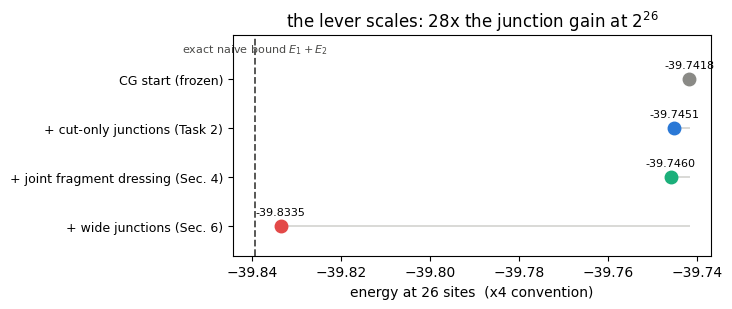

In [24]:
# --- Does the lever scale? The 26-site ledger, visually -----------------------
W26_F = RESULTS / "er26_wide.npz"
if not W26_F.exists():
    print("needs er26_wide.npz (run the Sec.-6 26q cell first)")
else:
    rows26 = [("CG start (frozen)", eCG, C_T1),
              ("+ cut-only junctions (Task 2)",
               min(r["energy"] for r in dc.load_runs(T2_RESULTS / "dnc26.npz")),
               C_R1),
              ("+ joint fragment dressing (Sec. 4)",
               min(r["energy"] for r in dc.load_runs(RESULTS / "er26_joint.npz")),
               C_R2),
              ("+ wide junctions (Sec. 6)",
               min(r["energy"] for r in dc.load_runs(W26_F)), C_IF)]
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    ys = np.arange(len(rows26))[::-1]
    for y, (lab, e, col) in zip(ys, rows26):
        ax.plot([rows26[0][1], e], [y, y], color="#d9d9d6", lw=1.4, zorder=2)
        ax.plot([e], [y], "o", ms=9, color=col, zorder=3)
        ax.annotate(f"{e:.4f}", xy=(e, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8)
    ax.axvline(E_naive26, color="#4a4a48", lw=1.3, ls="--", zorder=1)
    ax.annotate("exact naive bound $E_1+E_2$", xy=(E_naive26, ys[0] + 0.55),
                fontsize=8, color="#4a4a48", ha="center",
                annotation_clip=False)
    ax.set_yticks(ys); ax.set_yticklabels([r[0] for r in rows26], fontsize=9)
    ax.set_xlabel("energy at 26 sites  (x4 convention)")
    ax.set_title("the lever scales: 28x the junction gain at $2^{26}$")
    ax.set_ylim(-0.6, len(rows26) - 0.1)
    fig.tight_layout(); fig.savefig(FIGURES / "er_scale26.png", dpi=150,
                                    bbox_inches="tight")
    plt.show()